# Mini-Project 2
*Kim Concepcion Nielsen*

*Course : Numerical Scientific Computing 2026*

## Hardware Specs
* CPU Model: Quad-Core Intel Core i7
* CPU Cores: 4
* RAM: 16GB
* L2-buffer per core: 256 kB
* L3-buffer: 8 MB

## Operating System Information
* System version: macOS 13.7.8 (22H730)

## Library versions
* Python: 3.11.14

### Python packages (relevant for Mandelbrot / performance)

| Package     | Version |
|------------|--------|
| numpy      | 1.26.4 |
| numba      | 0.63.1 |
| matplotlib | 3.10.8 |
| line_profiler  | 5.0.2  |
| memory_profiler| 0.61.0 |

### Measurement Methodology
All benchmarks in this performance notebook have been carried out with perf_counter() to measure time execution. Additionally, all benchmarks are based on multiple runs to get an average perspective of the results. Some of the Python code in this notebook has been executed directly from a .py file as I have experienced issues running multiprocessing code directly from a Jupyter Notebook cell. Keep in mind, that results might vary depending on what hardware and software versions are used to run the code in this notebook. All relevant applied hardware and software versions have been documented in this notebook.

---

# Parallel Computing I

### Monte Carlo π

**Exercise 1: Serial Implementation**

In [6]:
import math, random, time, statistics
import matplotlib.pyplot as plt

def estimate_pi_serial(num_samples):
    hits_inside_circle = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            hits_inside_circle += 1
    return 4 * hits_inside_circle / num_samples

def do_serial():
    num_samples  = 10_000_000
    times        = []
    
    for _ in range(3):
        t0 = time.perf_counter()
        pi_estimate = estimate_pi_serial(num_samples)
        times.append(time.perf_counter() - t0)
    t_serial = statistics.median(times)

    print(f"pi estimate: {pi_estimate:.6f} (error: {abs(pi_estimate-math.pi):.6f})")
    print(f"Serial time: {t_serial:.3f}s")

if __name__ == '__main__':
    do_serial()
    do_serial()
    do_serial()

pi estimate: 3.141061 (error: 0.000531)
Serial time: 1.769s
pi estimate: 3.142204 (error: 0.000611)
Serial time: 1.758s
pi estimate: 3.141259 (error: 0.000333)
Serial time: 1.760s


Questions:
* How accurate is the estimate? Run several times — does it vary? *Yes the serial time varies, but the change is quite small*
* What is the serial time? This will be your speedup denominator in E3. *Serial time lies between 1.758-1.769 seconds*

**Exercise 2: Parallel Implementation**

In [ ]:
from multiprocessing import Pool
import os, random, time, statistics
import matplotlib.pyplot as plt
import psutil

def estimate_pi_chunk(num_samples):
    inside_circle = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside_circle += 1
    return inside_circle

def estimate_pi_parallel(num_samples, num_processes=4):
    samples_per_process = num_samples // num_processes
    tasks = [samples_per_process] * num_processes
    with Pool(processes=num_processes) as pool:
        results = pool.map(estimate_pi_chunk, tasks)
    return 4 * sum(results) / num_samples

if __name__ == '__main__':
    cores = psutil.cpu_count(logical=False)
    print(f'Number of cores: {cores}')
    
    num_samples = 10_000_000

    results = []
    for num_proc in range(1, cores + 1):
        times = []
        pi_0_est = 0
        
        for idx in range(3):
            t0 = time.perf_counter()
            pi_est = estimate_pi_parallel(num_samples, num_proc)
            
            t1 = time.perf_counter() - t0
            times.append(t1)
        
        t = statistics.median(times)        
        new_result = {
            'workers' : num_proc,
            'pi' : pi_est,
            't': t,
            'speedup': 0,
            'eff' : 0,
            's' : 0
        }
        
        results.append(new_result)

    # Compute speedups
    t0 = results[0]['t']
    for result in results:
        result['speedup'] = t0 / result['t']
        result['eff']     = result['speedup'] / result['workers']
        
        # avoid division by 0 :-P
        if result['workers'] > 1:
            result['s'] = (1/result['speedup'] - 1/result['workers']) / (1 - 1/result['workers'])
        
        print(f"{result['workers']:2d} workers t={result['t']:.3f}s pi={result['pi']:.6f} sp={result['speedup']:.3f} eff={result['eff']*100.0:.3f}% s={result['s']:.3f}")
    
    # Plotting
    workers   = [ r['workers'] for r in results ]
    times     = [ r['t'] for r in results ]
    speedups  = [ r['speedup'] for r in results ]

    plt.figure()
    plt.plot(workers, times, marker='o', label='Measured execution time vs # of cores')
    plt.xlabel('Workers (# of cores)')
    plt.ylabel('Execution Time [s]')
    plt.title('Execution time vs number of cores')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
    
    ideal = workers
    plt.figure()
    plt.plot(workers, ideal, 'k--', label='Ideal linear')
    plt.plot(workers, speedups, marker='o', label='Measured speedup vs # of cores')
    plt.xlabel('Workers (# of cores)')
    plt.ylabel('Speedup')
    plt.title('Speedup vs workers')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


```
Number of cores: 4
 1 workers t=1.979s pi=3.141551 sp=1.000 eff=100.000% s=0.000
 2 workers t=1.406s pi=3.141328 sp=1.407 eff=70.373% s=0.421
 3 workers t=1.095s pi=3.140851 sp=1.808 eff=60.257% s=0.330
 4 workers t=1.067s pi=3.141765 sp=1.855 eff=46.364% s=0.386
```

Questions:
* Do all worker counts give the same ˆπ? Why or why not? *No. When each created task executes estimate_pi_chunk() which generates new random x and y points. Because of this the pi values will never be identical*
* At which count do you first see a meaningful speedup? *Based on the execution time results, I would say that the first significant speedup already happens at 2 workers. The biggest speedup seems to be around 4 workers*

**Exercise 3: Analyze Results**

Parallel efficiency: E_p = S_p/p - fraction of ideal speedup per core (100%=perfect).
For each worker count (1 to cpu_count()), tabulate: workers | time (s) | speedup S_p | efficiency E_p (%)

Questions to discuss:
1. At which worker count $p^∗$ is speedup maximum? *Based on the code output above, the biggest speedup seems to be at 4 workers*
2. Does speedup plateau or drop beyond $p^∗$? Why? *From 3 to 4 workers, the speedup does not increase much and almost stays flat. This could be due to a higher portion of time is spent on IPC overhead, which is a sequential process.*
3. Back-solve implied serial fraction: $s=\frac{1/s_{p^*}-1/p^*}{1-1/p^*}$ what fraction of time is effectively serial (IPC overhead + spawning)? *According to the code output the serial fraction for e.g. 4 workers where we have maximum speedup, the serial fraction is 0.3854*

(Optional) Plot: workers (x) vs. speedup (y) — actual and ideal linear.

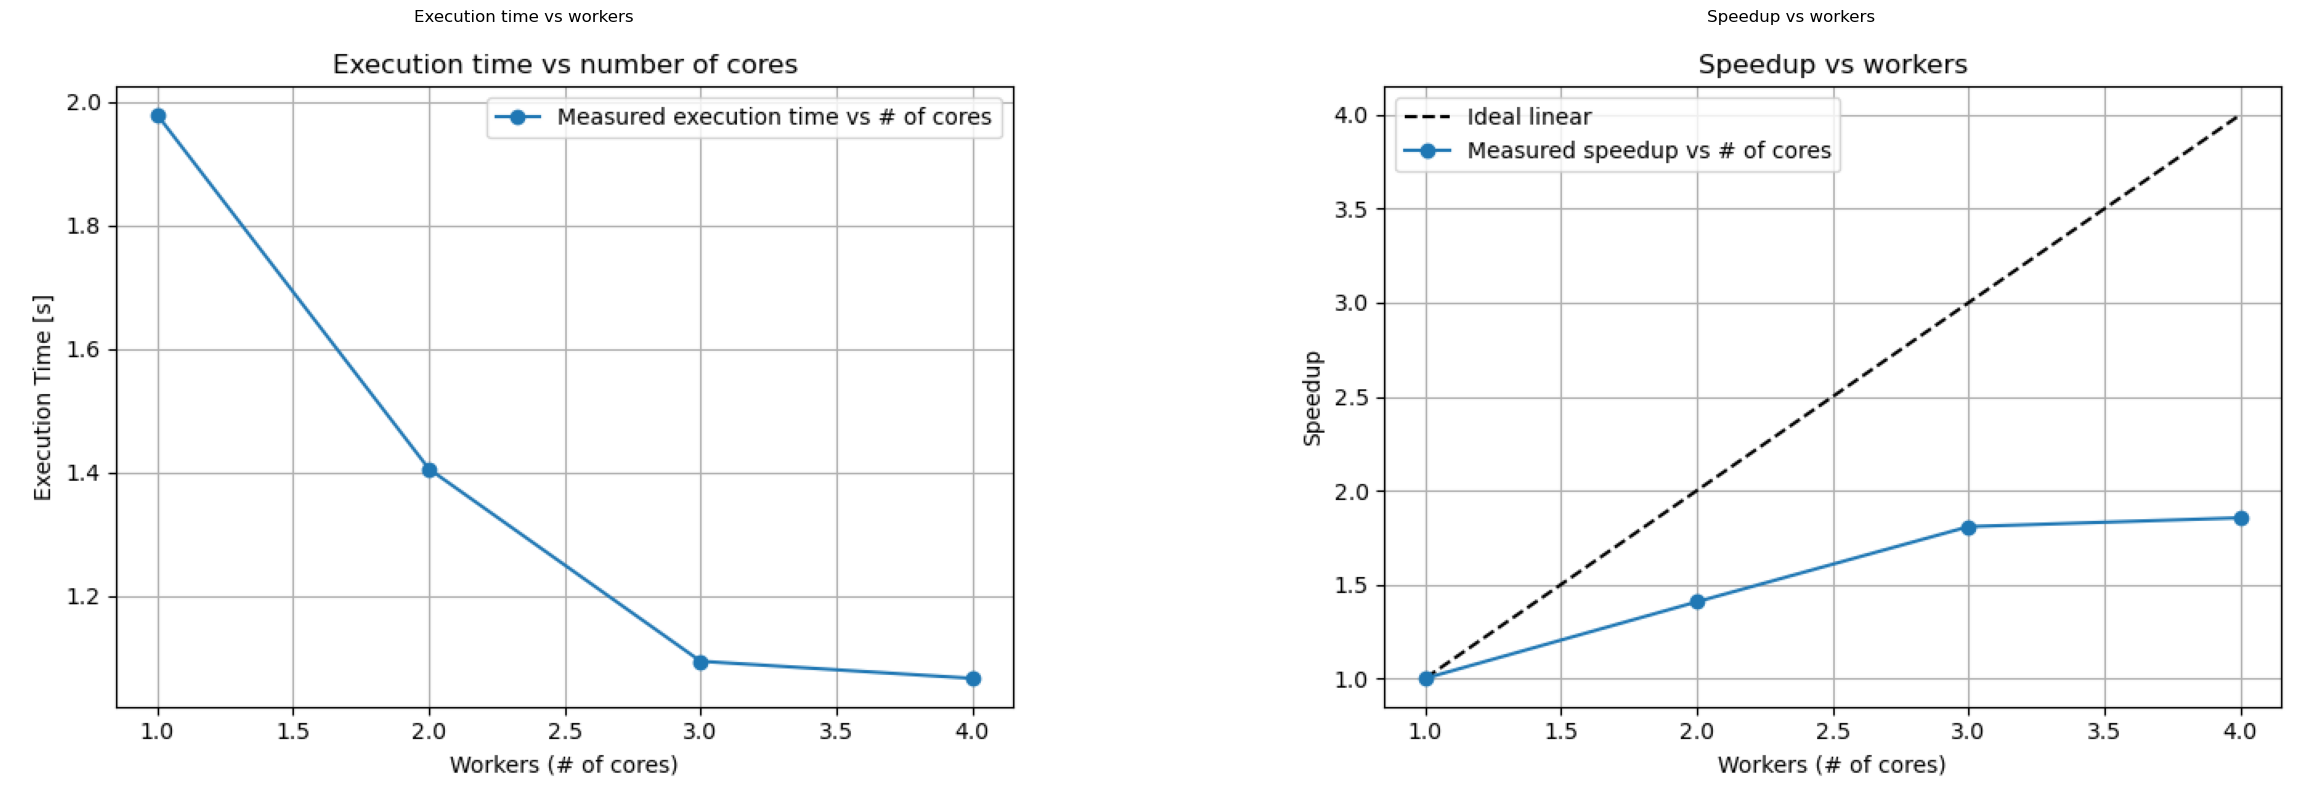

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('execution_time_vs_workers.png')
img2 = mpimg.imread('speedup_vs_workers.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Execution time vs workers')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('Speedup vs workers')
ax[1].axis('off')

plt.show()

### Parallel Mandelbrot

**M1 Refactor Code**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import statistics
import time

import numpy as np
from numba import njit, prange

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iteration  = 100 # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------

@njit
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def benchmark ( func , * args , n_runs =3) -> tuple:
    """ Time func , return median of n_runs . """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics . median ( times )
    
    print (f" Median : { median_t :.4f}s "
        f"( min ={ min( times ):.4f}, max ={ max( times ):.4f})")
    
    return median_t, result


if __name__ == '__main__':

    t, M = benchmark(mandelbrot_serial, N, x_min, x_max, y_min, y_max, max_iteration, n_runs=1) # Includes benchmark time to compile functions
    t, M = benchmark(mandelbrot_serial, N, x_min, x_max, y_min, y_max, max_iteration, n_runs=1) # Excludes benchmark time to compile functions

    # Plot Serial Mandelbrot
    from multiprocessing import Pool
    from pathlib import Path

    fig, ax = plt.subplots( figsize=(8,6) )
    im = ax.imshow(M, extent=[x_min, x_max, y_min, y_max], cmap='plasma', origin='lower', aspect='equal')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel('Re(c)')
    ax.set_ylabel('Im(c)')
    out = Path(__file__).parent / 'm1_serial_mandelbrot.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')

*Serial Mandelbrot vs L03 Mandelbrot*

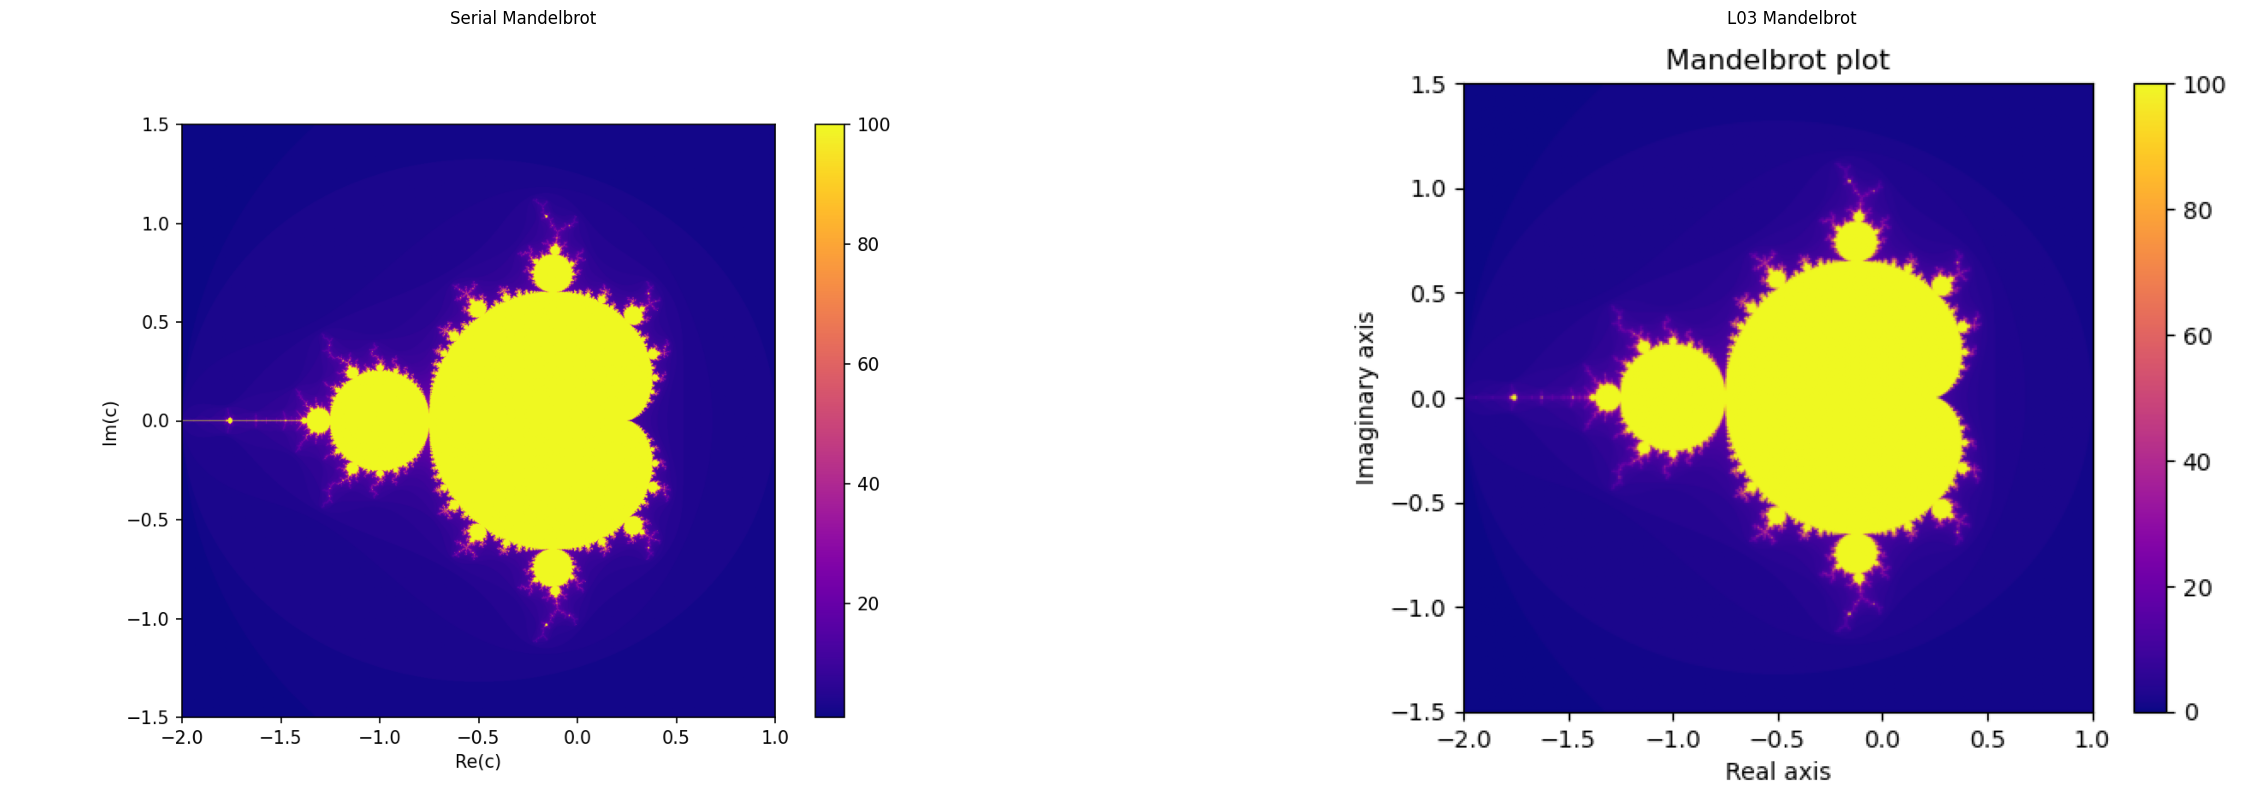

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('m1_serial_mandelbrot.png')
img2 = mpimg.imread('l03_mandelbrot.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Serial Mandelbrot')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('L03 Mandelbrot')
ax[1].axis('off')

plt.show()

The serial mandelbrot plot and mandelbrot plot from Lecture 3 appear quite similar.

**M2 Parallel Implementation**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
from pathlib import Path

import psutil
import time, os, statistics, matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iteration  = 100 # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------

@njit
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def _worker(args):
    return mandelbrot_chunk(*args)

def mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers=4):
    """
    Process mandelbrot chunks in parallel
    """
    chunk_size  = max(1, N // n_workers)
    chunks, row = [], 0
    
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end

    with Pool(processes=n_workers) as pool:
        pool.map(_worker, chunks) # un-timed warm-up: Numba JIT in workers
        parts = pool.map(_worker, chunks)
    
    return np.vstack(parts)

if __name__ == '__main__':
    cores = psutil.cpu_count(logical=False)
    result = mandelbrot_parallel( N, x_min, x_max, y_min, y_max, max_iteration, n_workers=cores )

    fig, ax = plt.subplots( figsize=(8,6) )
    im = ax.imshow(result, extent=[x_min, x_max, y_min, y_max], cmap='plasma', origin='lower', aspect='equal')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel('Re(c)')
    ax.set_ylabel('Im(c)')
    out = Path(__file__).parent / 'm2_parallel_mandelbrot.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')


*Parallel Mandelbrot vs Serial Mandelbrot results*

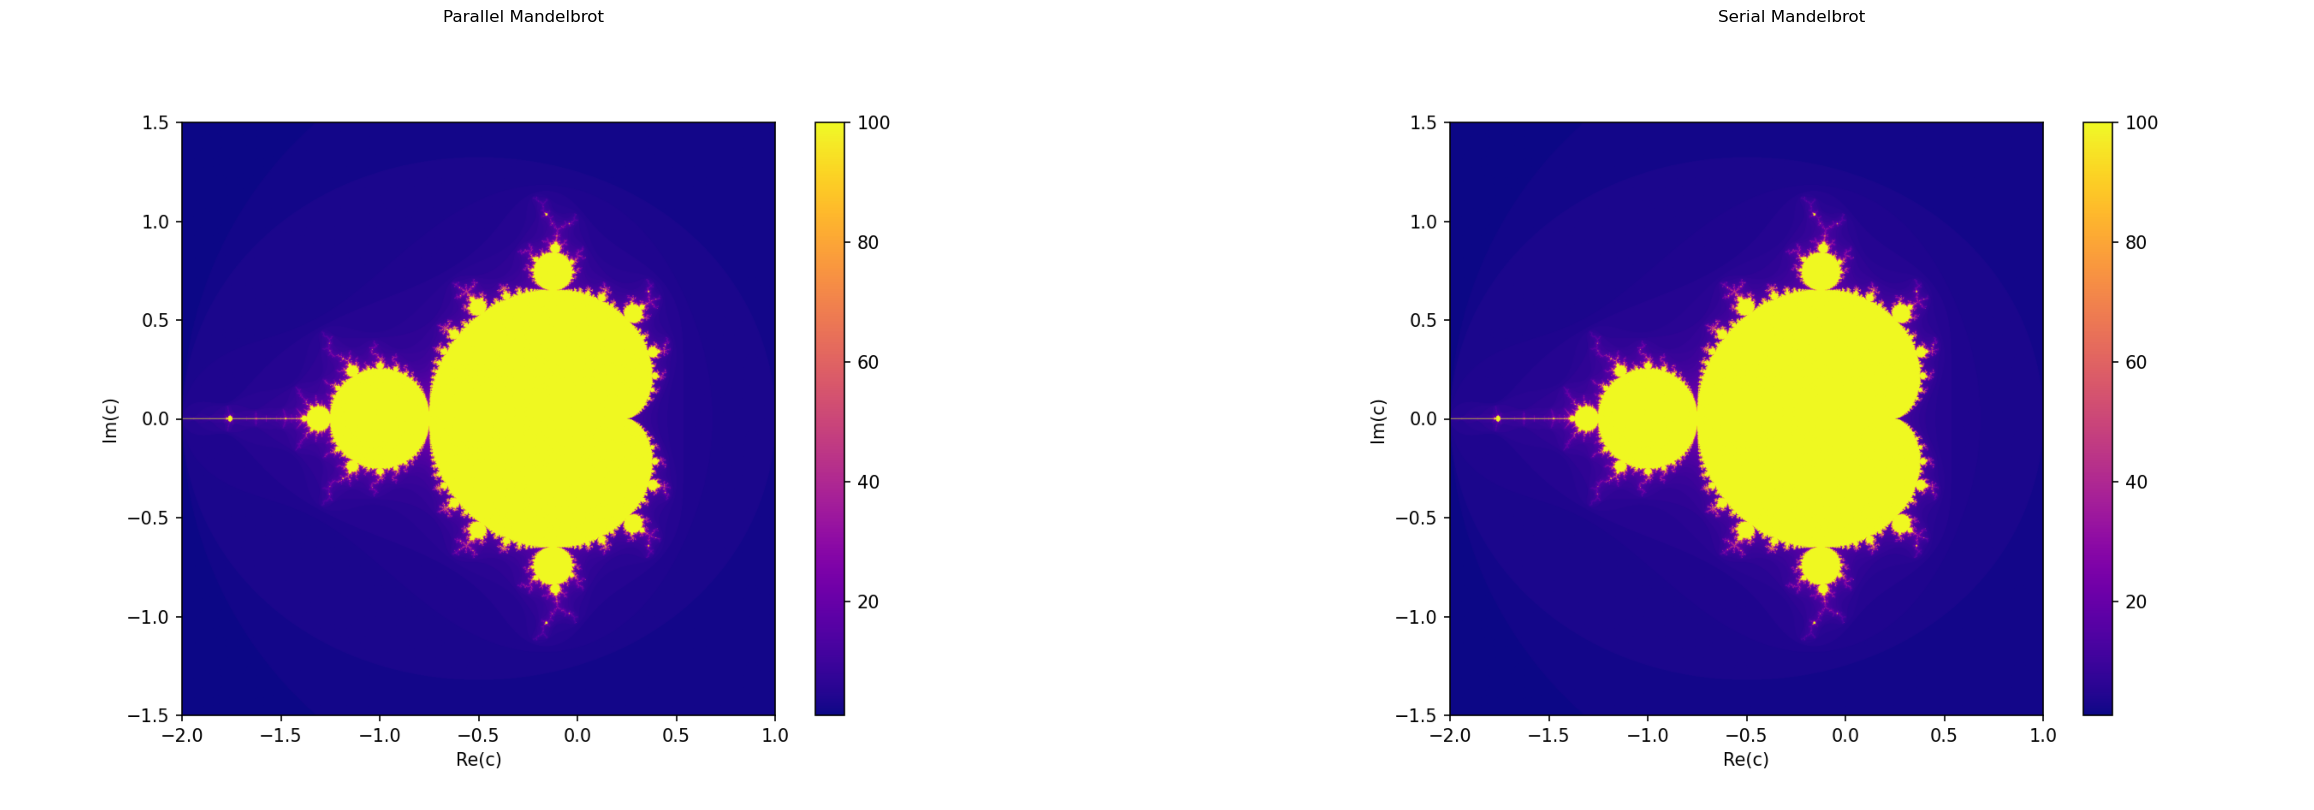

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('m2_parallel_mandelbrot.png')
img2 = mpimg.imread('m1_serial_mandelbrot.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Parallel Mandelbrot')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('Serial Mandelbrot')
ax[1].axis('off')

plt.show()

The parallel and serial mandelbrot plots appear quite similar.

**M3 Benchmark**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
from pathlib import Path

import psutil
import time, os, statistics, matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iter       = 100  # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------
@njit
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def _worker(args):
    return mandelbrot_chunk(*args)

# ----------------------------------------------------------------------------------------------------
# Main area
# ----------------------------------------------------------------------------------------------------

if __name__ == '__main__':

    # Serial baseline (Numba already warm after M1 warm-up)
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter)
        times.append(time.perf_counter() - t0)
    t_serial = statistics.median(times)
    
    cores = psutil.cpu_count(logical=False)
    for n_workers in range(1, cores + 1):
        chunk_size = max(1, N // n_workers)
        chunks, row = [], 0
        while row < N:
            end = min(row + chunk_size, N)
            chunks.append((row, end, N, x_min, x_max, y_min, y_max, max_iter))
            row = end

        with Pool(processes=n_workers) as pool:
            pool.map(_worker, chunks) # warm-up: Numba JIT in all workers
            times = []

            for _ in range(3):
                t0 = time.perf_counter()
                np.vstack(pool.map(_worker, chunks))
                times.append(time.perf_counter() - t0)
            t_par = statistics.median(times)
            speedup = t_serial / t_par
            print(f"{n_workers:2d} workers: {t_par:.3f}s, speedup={speedup:.2f}x, eff={speedup/n_workers*100:.0f}%")


*Code output*
```
 1 workers: 0.130s, speedup=0.81x, eff=81%
 2 workers: 0.073s, speedup=1.44x, eff=72%
 3 workers: 0.091s, speedup=1.15x, eff=38%
 4 workers: 0.061s, speedup=1.72x, eff=43%
```

*Speedup Table*
| workers   | Execution time | Speedup | Efficiency |
| -------- | ------- | ------- | -------|
| 1 | 0.130s | 0.81x | 81%
| 2 | 0.073s | 1.44x | 72%
| 3 | 0.091s | 1.15x | 38%
| 4 | 0.061s | 1.72x | 43%

---

# Parallel Computing II

### Exercises

**Exercise 1: Overhead vs. Granularity**

In [ ]:
from multiprocessing import Pool
import random, time, os
import matplotlib.pyplot as plt
import psutil

def monte_carlo_chunk(num_samples):
    """
    Estimate pi contributions for num_samples random points.
    """
    inside = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside += 1
    return inside

def test_granularity(total_work, chunk_size, n_proc, pool=None):
    n_chunks = total_work // chunk_size
    tasks = [chunk_size] * n_chunks
    t0 = time.perf_counter()
    if n_proc == 1 and pool is None:
        results = [monte_carlo_chunk(s) for s in tasks]
    elif pool is not None:
        results = pool.map(monte_carlo_chunk, tasks)
    return time.perf_counter() - t0, 4 * sum(results) / total_work

if __name__ == '__main__':
    results = []
    
    total_work = 1_000_000
    # n_proc = os.cpu_count() // 2
    n_proc = psutil.cpu_count(logical=False)
    
    chunk_sizes = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
    print(f"{'L':>12} | {'serial(s)':>12} | {'parallel(s)':>12} | {'pi'}")

    with Pool(processes=n_proc) as pool:
        for L in chunk_sizes:
            t_ser, _ = test_granularity(total_work, L, n_proc=1)
            t_par, pi = test_granularity(total_work, L, n_proc=n_proc, pool=pool)
            print(f"{L:12d} | {t_ser:12.4f} | {t_par:12.4f} | pi={pi:.4f}")
            
            new_entry = {
                'L':L,
                't_ser':t_ser,
                't_par':t_par,
                'pi':pi,
            }
            results.append( new_entry )
        
    # Plotting
    chunk_sizes    = [ r['L'] for r in results ]
    serial_times   = [ r['t_ser'] for r in results ]
    parallel_times = [ r['t_par'] for r in results ]
    
    plt.figure()
    plt.plot( chunk_sizes, serial_times, marker='o' )
    plt.xscale('log')
    plt.xlabel('Chunk size L')
    plt.ylabel('t serial time (s)')
    plt.title('Chunk size vs serial time')
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot( chunk_sizes, parallel_times, marker='o' )
    plt.xscale('log')
    plt.xlabel('Chunk size L')
    plt.ylabel('t parallel time (s)')
    plt.title('Chunk size vs Parallel time')
    plt.grid()
    plt.show()


```
           L |    serial(s) |  parallel(s) | pi
          10 |       0.3843 |       0.6286 | pi=3.1448
         100 |       0.1950 |       0.0687 | pi=3.1444
        1000 |       0.2098 |       0.0724 | pi=3.1418
       10000 |       0.2160 |       0.0738 | pi=3.1445
      100000 |       0.2187 |       0.0782 | pi=3.1415
     1000000 |       0.2181 |       0.2096 | pi=3.1429
```

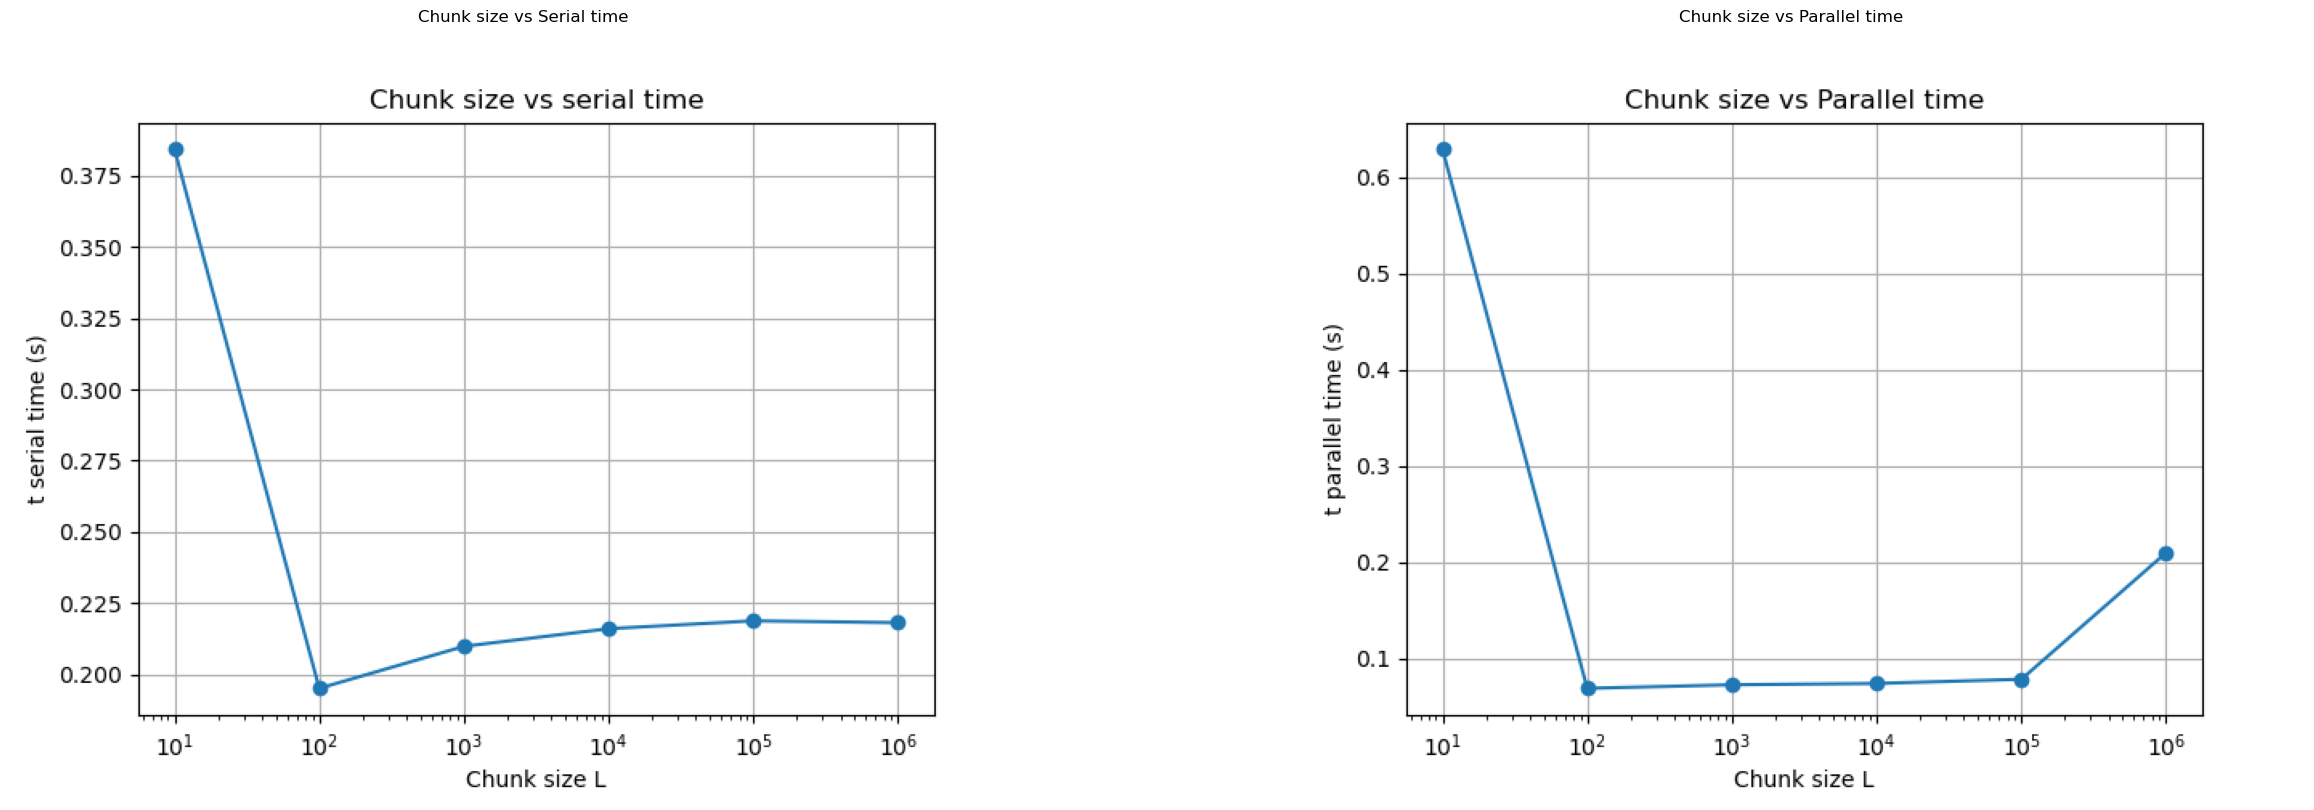

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('ex1_chunk_sz_vs_serial_time.png')
img2 = mpimg.imread('ex1_chunk_sz_vs_parallel_time.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Chunk size vs Serial time')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('Chunk size vs Parallel time')
ax[1].axis('off')

plt.show()

**Where is the optimal L for your machine?**

Based on the results, it seems that the lowest elapsed time for serial is for 100 chunks and for parallel the best chunk size is also 100.

**Exercise 2: Serial pipeline → parallel map**

In [ ]:
import random, time
from functools import reduce
from multiprocessing import Pool

N = 1_000_000
data = [random.randint(10, 100) for _ in range(N)]

def subtract_seven(x):
    return x - 7

if __name__ == '__main__':

    # Part 1
    t0 = time.perf_counter()
    result_ser = reduce(lambda a, b: a + b,
                        filter
                        (lambda x: x % 2 == 1,
                            map(subtract_seven, data)))
    t_serial = time.perf_counter() - t0

    # Part 2 - Move start of time after Pool() to exclude time it takes to spawn processes.
    with Pool() as pool:
        t0 = time.perf_counter()
        mapped = pool.map(subtract_seven, data)
        result_par = reduce(lambda a, b: a + b,
                            filter(lambda x: x % 2 == 1, mapped))
        t_parallel = time.perf_counter() - t0

    print(f"Serial:{t_serial:.4f}s result={result_ser}")
    print(f"Parallel:{t_parallel:.4f}s result={result_par}")
    print(f"Speedup:{t_serial/ t_parallel:.2f}x")


**Part 1 Serial**

Output:
```
Serial:0.1861s result=24248792
```

**Part 2 Parallel**
* Before running — predict: will Pool.map() be faster? Why or why not? *It might not be faster, as the amount of work is so small it might take even less time than the multiprocessing overhead.*
* Replace map(subtract seven, data) with pool.map(subtract seven, data)
* Time both versions and compare

Output:
```
Serial:0.1861s result=24248792
Parallel:1.4088s result=24248792
Speedup:0.13x
```

**After running**
* Was your prediction correct? *The results indicate that the elapsed time using the parallel approach is slower in this case. This aligns with my prediction.*
* How does this compare to the overhead curve you saw in E1? *Similar to what we saw in exercise 1, parallel execution introduces some overhead. When the compute-task is very small, the overhead from creating tasks and doing IPC could take up the majority of the time and thereby cause the parallel version to perform worse. This can e.g. Be seen on the parallel curve from exercise 1. The smallest chunk size results in a much higher execution time. It is even much higher than the worst serial test*

### Milestones

**Milestone 1 - Chunked Mandelbrot**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
from pathlib import Path

import psutil
import time, os, statistics, matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iteration  = 100 # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------

@njit(cache=True) # avoid that every new worker process re-compiles the numba function from scratch.
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def _worker(args):
    return mandelbrot_chunk(*args)

def mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers=4, n_chunks=None, pool=None):
    """
    Process mandelbrot chunks in parallel
    """
    if n_chunks is None:
        n_chunks = n_workers
    # print(f'n chunks: [{n_chunks}]')

    chunk_size  = max(1, N // n_chunks)
    chunks, row = [], 0
    
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end

    if pool is not None:
        return np.vstack( pool.map(_worker,chunks) )
    
    tiny = [ (0,8,8,x_min,x_max,y_min,y_max,max_iter) ]

    with Pool(processes=n_workers) as p:
        p.map(_worker, tiny) # warm-up -> load JIT cache in workers
        parts = p.map(_worker, chunks)
    return np.vstack(parts)

def benchmark ( func , * args , n_runs =3) -> tuple:
    """ Time func , return median of n_runs . """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics . median ( times )
    
    print (f" Median : { median_t :.4f}s "
        f"( min ={ min( times ):.4f}, max ={ max( times ):.4f})")
    
    return median_t, result

if __name__ == '__main__':
    cores = psutil.cpu_count(logical=False)
    
    t, M = benchmark(mandelbrot_parallel, N, x_min, x_max, y_min, y_max, max_iteration, cores)

    fig, ax = plt.subplots( figsize=(8,6) )
    im = ax.imshow(M, extent=[x_min, x_max, y_min, y_max], cmap='plasma', origin='lower', aspect='equal')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel('Re(c)')
    ax.set_ylabel('Im(c)')
    out = Path(__file__).parent / 'chunked_mandelbrot_m1_4_parallel_mandelbrot.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')

    t, M = benchmark(mandelbrot_parallel, N, x_min, x_max, y_min, y_max, max_iteration, cores, cores*4)

    fig, ax = plt.subplots( figsize=(8,6) )
    im = ax.imshow(M, extent=[x_min, x_max, y_min, y_max], cmap='plasma', origin='lower', aspect='equal')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel('Re(c)')
    ax.set_ylabel('Im(c)')
    out = Path(__file__).parent / 'chunked_mandelbrot_m1_16_parallel_mandelbrot.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')

**Chunked Mandelbrot vs Serial Mandelbrot from L04**

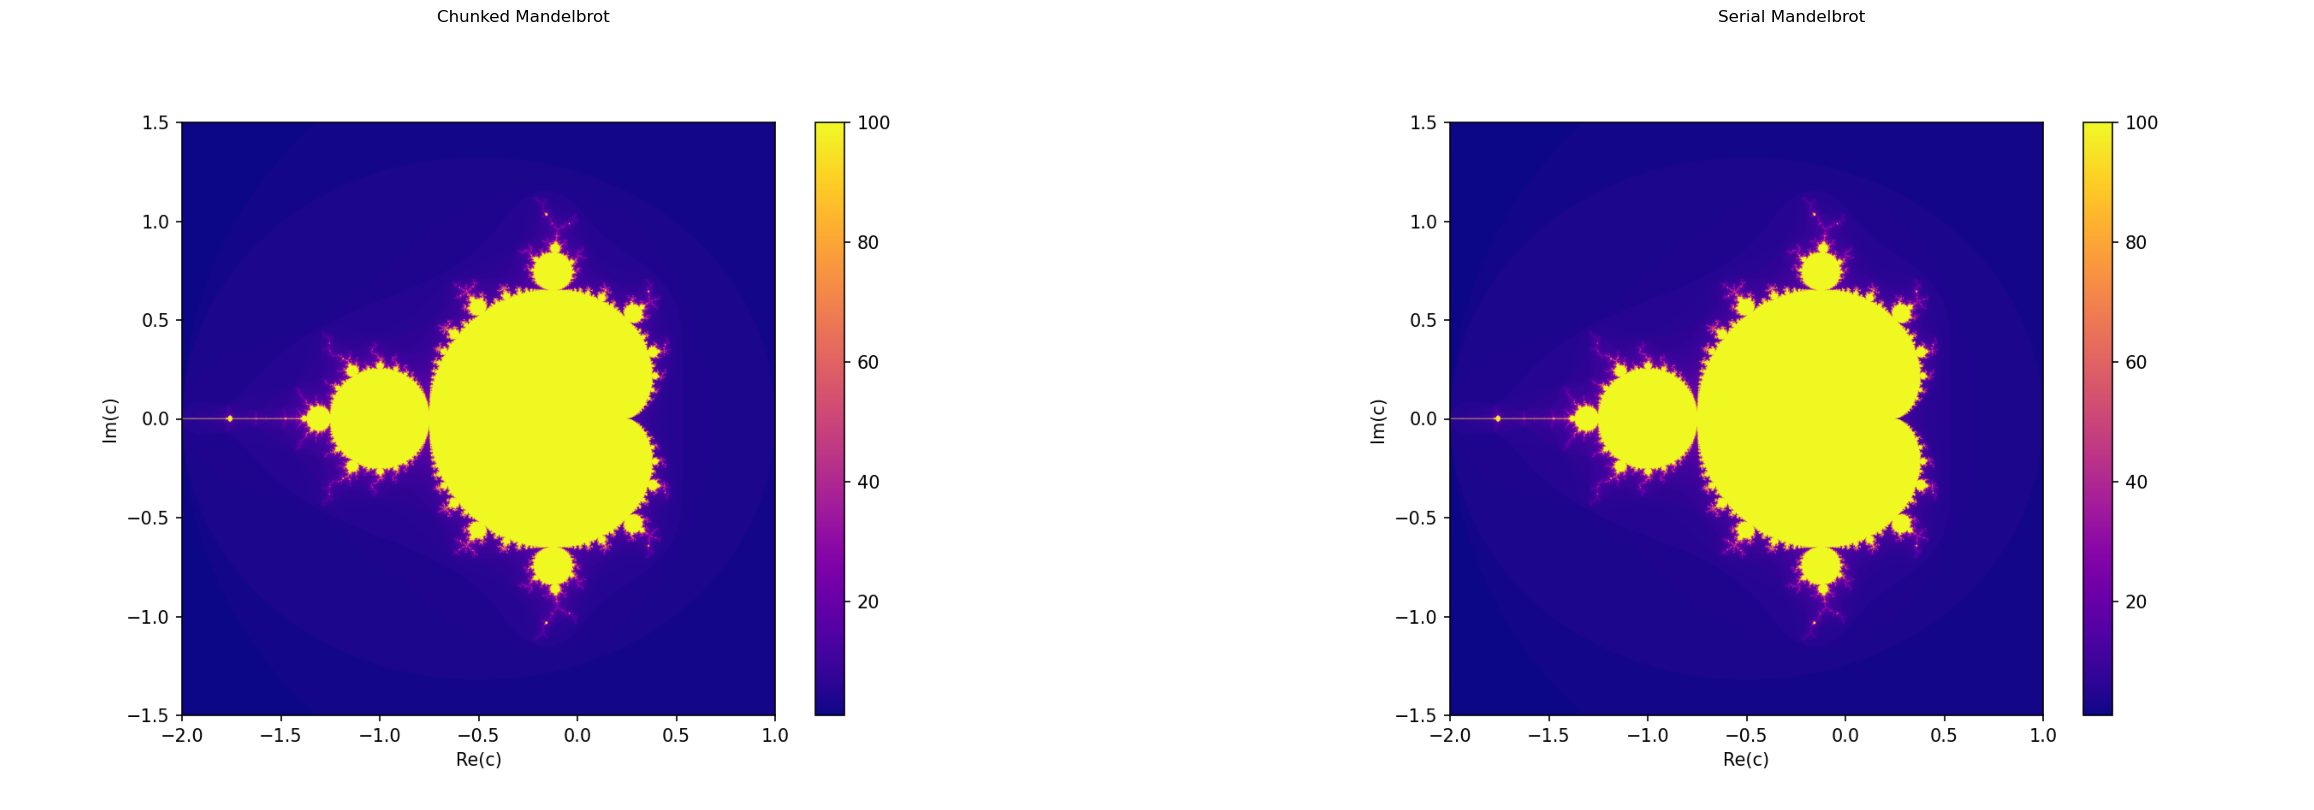

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('chunked_mandelbrot_m1_4_parallel_mandelbrot.png')
img2 = mpimg.imread('m1_serial_mandelbrot.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Chunked Mandelbrot')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('Serial Mandelbrot')
ax[1].axis('off')

plt.show()

The chunked Mandelbrot plot appears very similar to the serial mandelbrot plot.

*Re-run the L04 worker-count benchmark with n chunks = 4 × n workers; note any change?*

```
Median : 2.4429s ( min =2.1204, max =2.5796)
Median : 2.1002s ( min =2.0992, max =2.1709)
```

No major changes were observed. The average elapsed time based on three benchmarks indicates that using 4 or 16 chunks results in elapsed times that are some hundreds of milliseconds apart.

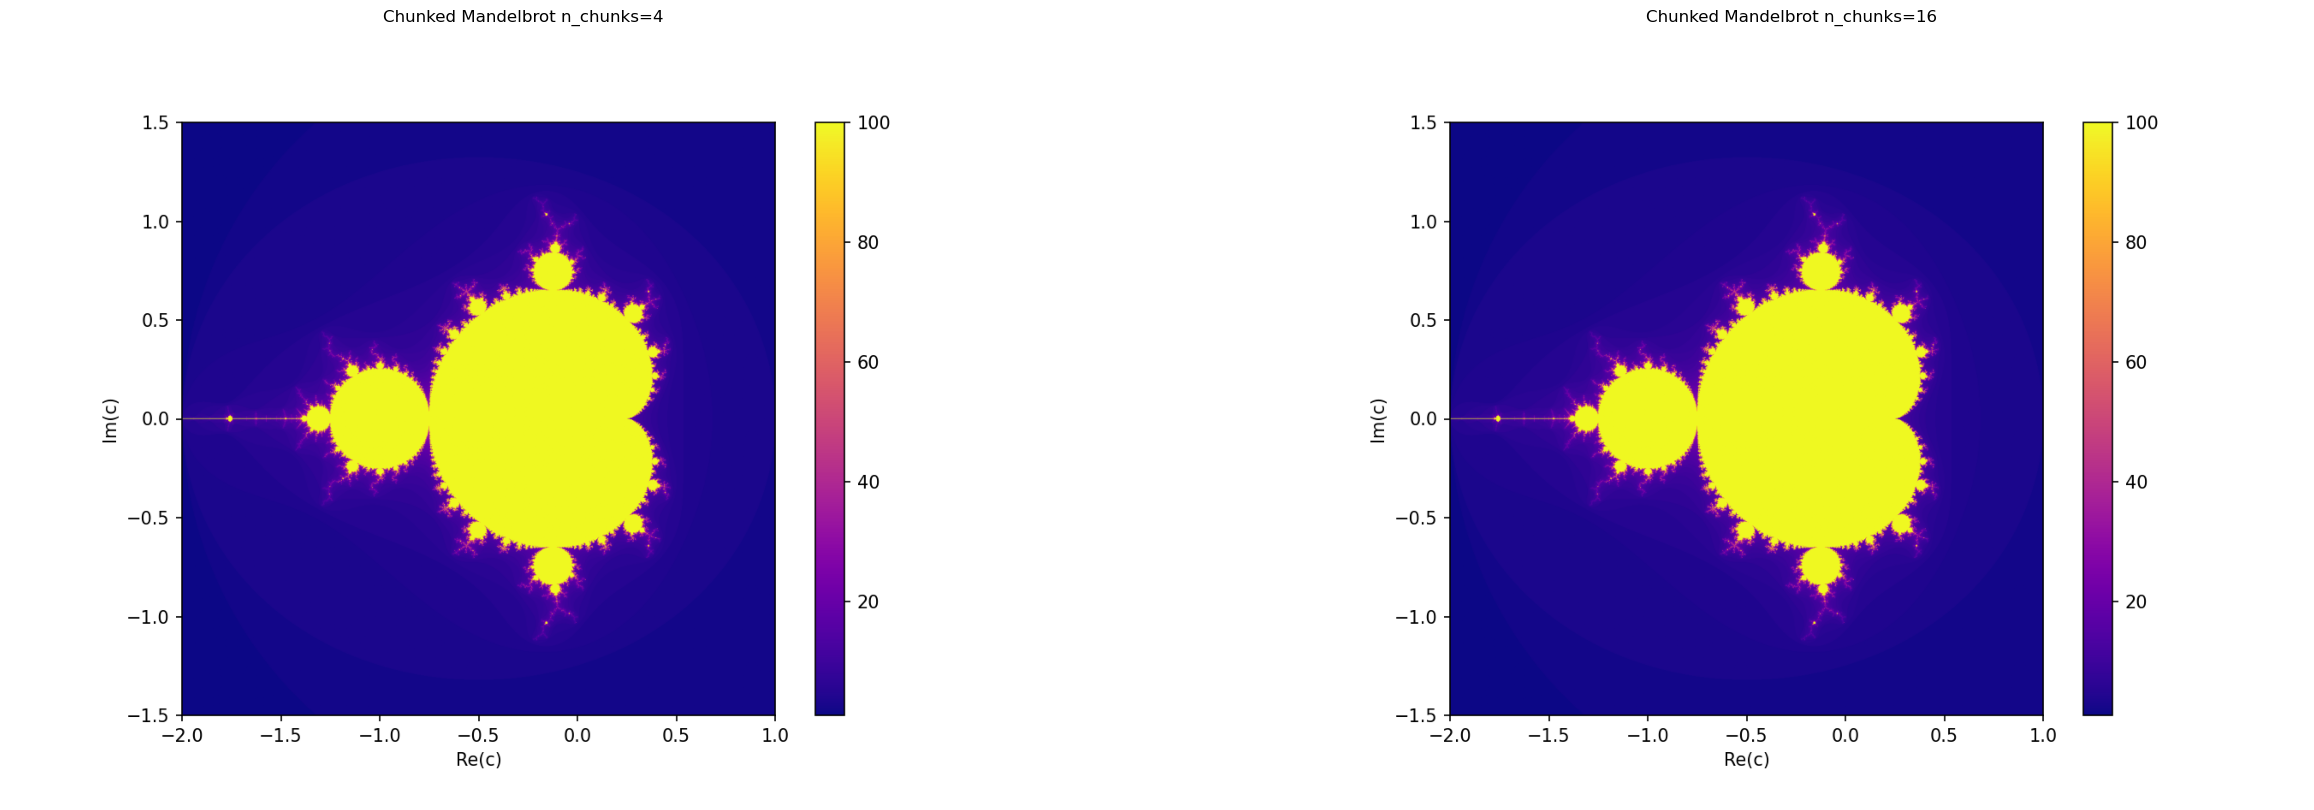

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('chunked_mandelbrot_m1_4_parallel_mandelbrot.png')
img2 = mpimg.imread('chunked_mandelbrot_m1_16_parallel_mandelbrot.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('Chunked Mandelbrot n_chunks=4')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('Chunked Mandelbrot n_chunks=16')
ax[1].axis('off')

plt.show()

**Milestone 2 - Optimal Chunk Size**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
from pathlib import Path

import time, os, statistics, matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iteration  = 100 # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------

@njit(cache=True) # avoid that every new worker process re-compiles the numba function from scratch. Instead, new workers can load from generated __pycache__ folder.
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def _worker(args):
    return mandelbrot_chunk(*args)

def mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers=4, n_chunks=None, pool=None):
    """
    Process mandelbrot chunks in parallel
    """
    if n_chunks is None:
        print('No n_chunks specified...')
        return
    
    chunk_size  = max(1, N // n_chunks)
    chunks, row = [], 0
    
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end

    if pool is not None:
        return np.vstack( pool.map(_worker,chunks) )

def benchmark ( func , * args , n_runs =3) -> tuple:
    """ Time func , return median of n_runs . """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics.median( times )
    return median_t, result

if __name__ == '__main__':

    # Measure serial wall time
    T1, _ = benchmark(mandelbrot_serial, N, x_min, x_max, y_min, y_max, max_iteration, n_runs=3)
    print(f'T1 (Baseline serial wall time): {T1:.3f}s')

    optimum_n_workers = 4
    n_chunks          = [ 1, 2, 4, 8, 16 ]
    results           = []

    with Pool( optimum_n_workers ) as pool:
        # warm-up -> load JIT cache in workers
        tiny = [ (0,8,8,x_min,x_max,y_min,y_max,max_iteration) ]
        pool.map(_worker, tiny) # warm-up -> load JIT cache in workers

        # Sweep number of chunks
        for n_chunk in n_chunks:
            t, _ = benchmark(mandelbrot_parallel, N, x_min, x_max, y_min, y_max, max_iteration, optimum_n_workers, n_chunk * optimum_n_workers, pool)

            new_results = {
                'n_workers': optimum_n_workers,
                'n_chunks' : n_chunk * optimum_n_workers,
                'time'     : t,
                'lif'      : (optimum_n_workers * t / T1) - 1 # Load imbalance factor
            }

            results.append( new_results )

    n_workers = [ r['n_workers'] for r in results ]
    n_chunks  = [ r['n_chunks'] for r in results ]
    times     = [ r['time'] for r in results ]
    lifs      = [ r['lif'] for r in results ]

    # Display results
    for i in range( len(results) ):
        speedup = T1 / times[i]
        print(f'Workers: {n_workers[i]}, n_chunks: {n_chunks[i]}, time: {times[i]:.3f}s, speedup: {speedup:.3f}, lif: {lifs[i]:.3f}')


*Output*

Based on L04, the optimal amount of cores was 4, so this experiment is based on using 4 cores.

```
T1 (Baseline serial wall time): 0.078s
Workers: 4, n_chunks: 4, time: 0.048s, speedup: 1.631, lif: 1.453
Workers: 4, n_chunks: 8, time: 0.033s, speedup: 2.356, lif: 0.698
Workers: 4, n_chunks: 16, time: 0.030s, speedup: 2.593, lif: 0.543
Workers: 4, n_chunks: 32, time: 0.029s, speedup: 2.647, lif: 0.511
Workers: 4, n_chunks: 64, time: 0.028s, speedup: 2.757, lif: 0.451
```

The biggest speedup seems to be at 64 chunks and 4 workers.
In this case, the ideal chunk size is actually bigger than the typical sweet spot of 4-8 times the number of workers.

**Milestone 3 - Comprehensive Analysis**

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Kim Nielsen ]
Course : Numerical Scientific Computing 2026
"""

# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from multiprocessing import Pool
from pathlib import Path

import time, os, statistics, matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange
import os
import matplotlib.pyplot as plt
import psutil

# ----------------------------------------------------------------------------------------------------
# Parameters
# ----------------------------------------------------------------------------------------------------
N              = 1024 # Same width & height
x_min          = -2.0 # min point on real axis
x_max          = 1.0  # max point on real axis
y_min          = -1.5 # min point on imaginary axis
y_max          = 1.5  # max point on imaginary axis
max_iteration  = 100 # We set a max iteration as number not part of Mandelbrot set will result in diverging and will keep going forever.

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------

@njit(cache=True) # avoid that every new worker process re-compiles the numba function from scratch. Instead, new workers can load from generated __pycache__ folder.
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    """
    Calls whole grid as a single chunk
    """
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

def _worker(args):
    return mandelbrot_chunk(*args)

def mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers=4, n_chunks=None, pool=None):
    """
    Process mandelbrot chunks in parallel
    """
    if n_chunks is None:
        print('No n_chunks specified...')
        return
    
    chunk_size  = max(1, N // n_chunks)
    chunks, row = [], 0
    
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end

    if pool is not None:
        return np.vstack( pool.map(_worker,chunks) )

def benchmark ( func , * args , n_runs =3) -> tuple:
    """ Time func , return median of n_runs . """
    times = []
    for _ in range ( n_runs ):
        t0 = time . perf_counter ()
        result = func (* args )
        times . append ( time . perf_counter () - t0 )
    
    median_t = statistics.median( times )
    return median_t, result

if __name__ == '__main__':

    # Measure serial wall time
    T1, _ = benchmark(mandelbrot_serial, N, x_min, x_max, y_min, y_max, max_iteration, n_runs=3)
    print(f'T1 (Baseline serial wall time): {T1:.3f}s')

    optimum_n_workers = 4
    n_chunks          = [ 1, 2, 4, 8, 16 ]
    results           = []

    with Pool( processes=optimum_n_workers ) as pool:
        # warm-up -> load JIT cache in workers
        tiny = [ (0,8,8,x_min,x_max,y_min,y_max,max_iteration) ]
        pool.map(_worker, tiny) # warm-up -> load JIT cache in workers

        # Sweep number of chunks
        for n_chunk in n_chunks:
            t, M = benchmark(mandelbrot_parallel, N, x_min, x_max, y_min, y_max, max_iteration, optimum_n_workers, n_chunk * optimum_n_workers, pool)

            new_results = {
                'n_workers': optimum_n_workers,
                'n_chunks' : n_chunk * optimum_n_workers,
                'time'     : t,
                'lif'      : (optimum_n_workers * t / T1) - 1 # Load imbalance factor
            }
            results.append( new_results )

    # Display results
    n_workers = [ r['n_workers'] for r in results ]
    n_chunks  = [ r['n_chunks'] for r in results ]
    times     = [ r['time'] for r in results ]
    lifs      = [ r['lif'] for r in results ]
    for i in range( len(results) ):
        speedup = T1 / times[i]
        print(f'Workers: {n_workers[i]}, n_chunks: {n_chunks[i]}, time: {times[i]:.3f}s, speedup: {speedup:.3f}, lif: {lifs[i]:.3f}')
    
    # ----- Sweep number of workers...
    print('-'*100)
    results = []
    optimum_n_chunks = 64
    cores = psutil.cpu_count(logical=False)
    for n_workers in range(1, cores + 1):
        with Pool( processes=n_workers ) as pool:
            # warm-up -> load JIT cache in workers
            tiny = [ (0,8,8,x_min,x_max,y_min,y_max,max_iteration) ]
            pool.map(_worker, tiny) # warm-up -> load JIT cache in workers

            t, M = benchmark(mandelbrot_parallel, N, x_min, x_max, y_min, y_max, max_iteration, n_workers, optimum_n_chunks, pool)
            new_results = {
                'n_workers': n_workers,
                'n_chunks' : optimum_n_chunks,
                'time'     : t,
                'lif'      : (n_workers * t / T1) - 1 # Load imbalance factor
            }
            results.append( new_results )
    
    # Plot actual vs ideal speedups
    ideal_speedup = [ r['n_workers'] for r in results ]
    actual_speeup = [ T1 / r['time'] for r in results ]

    fig, ax = plt.subplots()
    ax.plot( [r['n_workers'] for r in results], actual_speeup, 'o-', label='Actual' )
    ax.plot( [r['n_workers'] for r in results], ideal_speedup, '--', label='Ideal' )
    ax.set_xlabel('Number of workers')
    ax.set_ylabel('Speedup')
    ax.set_title('Actual vs Ideal Speedup')
    ax.grid()
    ax.legend()

    out = Path(__file__).parent / 'comprehensive_analysis_m3.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')

*1. Speedup table*

**Benchmark Table (based on results from MP1 report and chunked parallel Mandelbrot with optimal chunk size)**
| Version   | Time | Speedup |
| -------- | ------- | ------- |
| Naive    | 10.260s | 1x      |
| Numpy    | 0.870s  | 11.8x   |
| Numba    | 0.075s  | 136.9x  |
| Parallel | 0.028s  | 366.4x  |

*2. Speedup vs. core count*

Actual vs Ideal (linear)



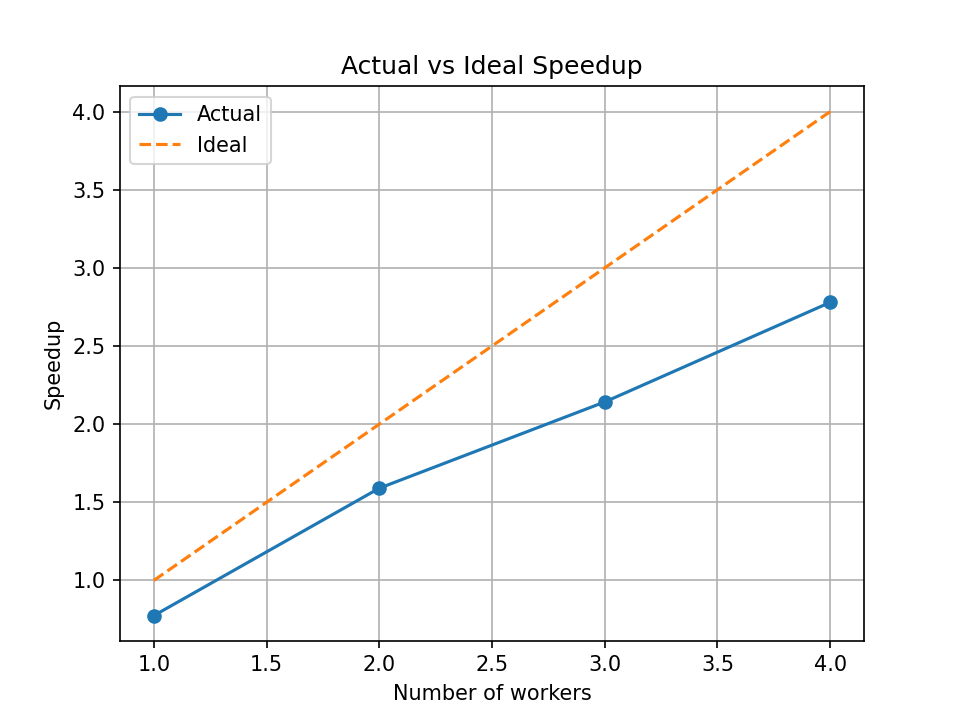

In [5]:
from IPython.display import Image, display
display(Image(filename="comprehensive_analysis_m3.png", width=600))

Back-solve implied s:
* Speedup here is based on optimal chunk size with parallel Mandelbrot vs serial Numba baseline.
* Speedup compared to serial Numba baseline of 0.078s, as we got from milestone 2 optimal chunk size, is 0.078/0.028=2.757

$$
s = \frac{ \frac{1}{2.757} - \frac{1}{4} }{ 1 - \frac{1}{4} } = 0,1503
$$

This means that the program has an effective serial fraction of about 15%.

Is your s smaller than your L04 result?
* From L04 milestone 3, I measured execution time to be 0.061s for 4 workers without configuring the chunk size.
* Speedup compared to serial Numba baseline of 0.078s, as we got from milestone 2 optimal chunk size, is 0.078/0.061=1.278

$$
s = \frac{ \frac{1}{1.278} - \frac{1}{4} }{ 1 - \frac{1}{4} } = 0,7099
$$

This means that the program has an effective serial fraction of about 70%. A much higher portion than the chunked Mandelbrot version.
This also suggests that the chunked Mandelbrot version implementation has better load balance.

*Brief recommendation*

* What settings give the best time? **

* Is parallelisation worth it on your
hardware?

* Compare speedup and LIF to your serial Numba baseline

* Write 2–3 sentences in your performance notebook

*Based on the experiements, the best settings was obtained using 4 cores and a chunk size of 64. By comparison to the serial Numba baseline, the speedup was at 2.757 with a low load imbalance factor LIF at 0.451 and the serial fraction at about 15% This indicates a good load balanace and suggests that only a small amount of the program is sequential. All in all, parallelization definitely results in bigger speedup. This is clearly evident based on the previously indicated speedup table.*

---

# Dask Local

### Exercises

**Exercise 1: Dask Delayed - Lazy Evaluation**

In [15]:
import dask, random, time, statistics
from dask import delayed

def monte_carlo_chunk(n_samples):
    inside = 0
    for _ in range(n_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside += 1
    return inside

n_chunks_list = [1, 4, 8, 16, 32, 64]

for n_chunks in n_chunks_list:
    total = 1_000_000
    samples = total // n_chunks 

    # Serial baseline
    t0 = time.perf_counter()
    results = [monte_carlo_chunk(samples) for _ in range(n_chunks)]
    t_serial = time.perf_counter() - t0
    print(f"n_chunks: {n_chunks} Serial:{t_serial:.3f}s pi={4*sum(results)/total:.4f}")

    # Dask delayed -- task graph is built, not executed yet
    tasks = [delayed(monte_carlo_chunk)(samples) for _ in range(n_chunks)]
    t0 = time.perf_counter()
    results = dask.compute(*tasks)
    t_dask = time.perf_counter() - t0
    print(f"n_chunks: {n_chunks} Dask:{t_dask:.3f}s pi={4*sum(results)/total:.4f}")
    print()

    # Visualise (requires: conda install python-graphviz)
    dask.visualize(*tasks, filename='task_graph_' + str(n_chunks) + '.png')

n_chunks: 1 Serial:0.253s pi=3.1432
n_chunks: 1 Dask:0.252s pi=3.1424

n_chunks: 4 Serial:0.233s pi=3.1407
n_chunks: 4 Dask:0.240s pi=3.1414

n_chunks: 8 Serial:0.239s pi=3.1391
n_chunks: 8 Dask:0.229s pi=3.1392

n_chunks: 16 Serial:0.235s pi=3.1414
n_chunks: 16 Dask:0.234s pi=3.1402

n_chunks: 32 Serial:0.229s pi=3.1441
n_chunks: 32 Dask:0.240s pi=3.1421

n_chunks: 64 Serial:0.226s pi=3.1424
n_chunks: 64 Dask:0.250s pi=3.1405



* Which tasks can run in parallel? 

*monte_carlo_chunk method.*


* How does overhead scale with very small chunks? 

*If we make make n_chunks bigger it means that each chunk gets smaller. If we increase number of chunks too much, the overhead time might dominate as it exceeds the duration of performing the work.*

* What speedup (or slowdown) did you observe, and why? 

*I do not see any significant speedup using Dask. I suspect the execution time might be dominated by Python-level operations such as random.random(), which use the global interpreter lock (GIL). Dask also by default uses threads for scheduling, meaning it does not apply true parallelism and is therefore unable to work around GIL. Consequently, this leads the program to a performance that is somewhat similar to sequential performance.*

**Exercise 2: LocalCluster & Dashboard**

In [ ]:
from dask.distributed import Client, LocalCluster
import dask
from dask import delayed
import time, random

def monte_carlo_chunk(n_samples):
    inside = 0
    for _ in range(n_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside += 1
    return inside

if __name__ == "__main__":

    n_chunks = 8

    # Create local cluster; start with max workers -- scale() adjusts without restarting
    cluster = LocalCluster(n_workers=8, threads_per_worker=1)
    client = Client(cluster)
    print(f"Dashboard: {client.dashboard_link}")
    # --> open the printed URL in your browser

    time.sleep(5.0)

    total = 200_000_000
    samples = total // n_chunks 

    # Rerun E1 tasks; LocalCluster scheduler takes over

    # ----- Test with 2 workers -----
    n = 2
    print(f'n workers: {n}')
    cluster.scale(n)
    client.wait_for_workers(n)
    tasks   = [delayed(monte_carlo_chunk)(samples) for _ in range(n_chunks)]
    results = dask.compute(*tasks)

    n = 12
    print(f'n workers: {n}')
    cluster.scale(n)
    client.wait_for_workers(n)
    tasks   = [delayed(monte_carlo_chunk)(samples) for _ in range(n_chunks)]
    results = dask.compute(*tasks)


    input('Press Enter to proceed...')

    # Terminate
    client.close()
    cluster.close()


c:\Users\Kim\miniforge3\envs\nsc2026\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 62015 instead
  warnings.warn(
c:\Users\Kim\miniforge3\envs\nsc2026\Lib\contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.32s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


Dashboard: http://127.0.0.1:62015/status


2026-03-23 17:08:42,251 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:62057' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'monte_carlo_chunk-ffed160e-4b99-4152-a2e3-a592100c6a90'} (stimulus_id='handle-worker-cleanup-1774282122.25097')
2026-03-23 17:08:42,253 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:62059' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'monte_carlo_chunk-db2d0d12-a1e9-4fda-87b7-0618209bbd1b'} (stimulus_id='handle-worker-cleanup-1774282122.2533226')
2026-03-23 17:08:42,256 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:62058' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'monte_carlo_chunk-9bceebcb-b20f-4a22-bbd4-f4242b456ef5'} (stimulus_id='handle-worker-cleanup-1774282122.2556214')
2026-03-23 17:08:42,265 - distributed.scheduler - WARNING - Removing worker 'tcp://127.

n workers: 1


* Try varying n workers (2, 4, 8) — does the task stream change? *Yes. When we increase the amount of workers, tasks are distributed across more workers. I tried to distribute 8 tasks across first 2 and later 12 workers. My observations were that for 2 workers, both workers distribute 4 tasks to each and then runs them in parallel. The invidual  worker executes the the 4 tasks sequentially. With 12 workers, I observated that only 8 workers were in use. This makes sense, since I have 8 tasks and I have 8 workers that can execute one Monte carlo task on its own.*
* Observe: are all workers busy? Are there any stragglers? *I noticed for the experiment with 12 workers that not all workers were equally busy. Some were 100% utilized, while others were e.g. 18% or 42% The results can be see on image below.*
* What did you see in the task stream? *I observed as mentioned before that for 2 workers, they were each assigned 4 tasks each. With 12 workers, I observed that 8 workers were each assigned a task. This can also be seen on image below.*

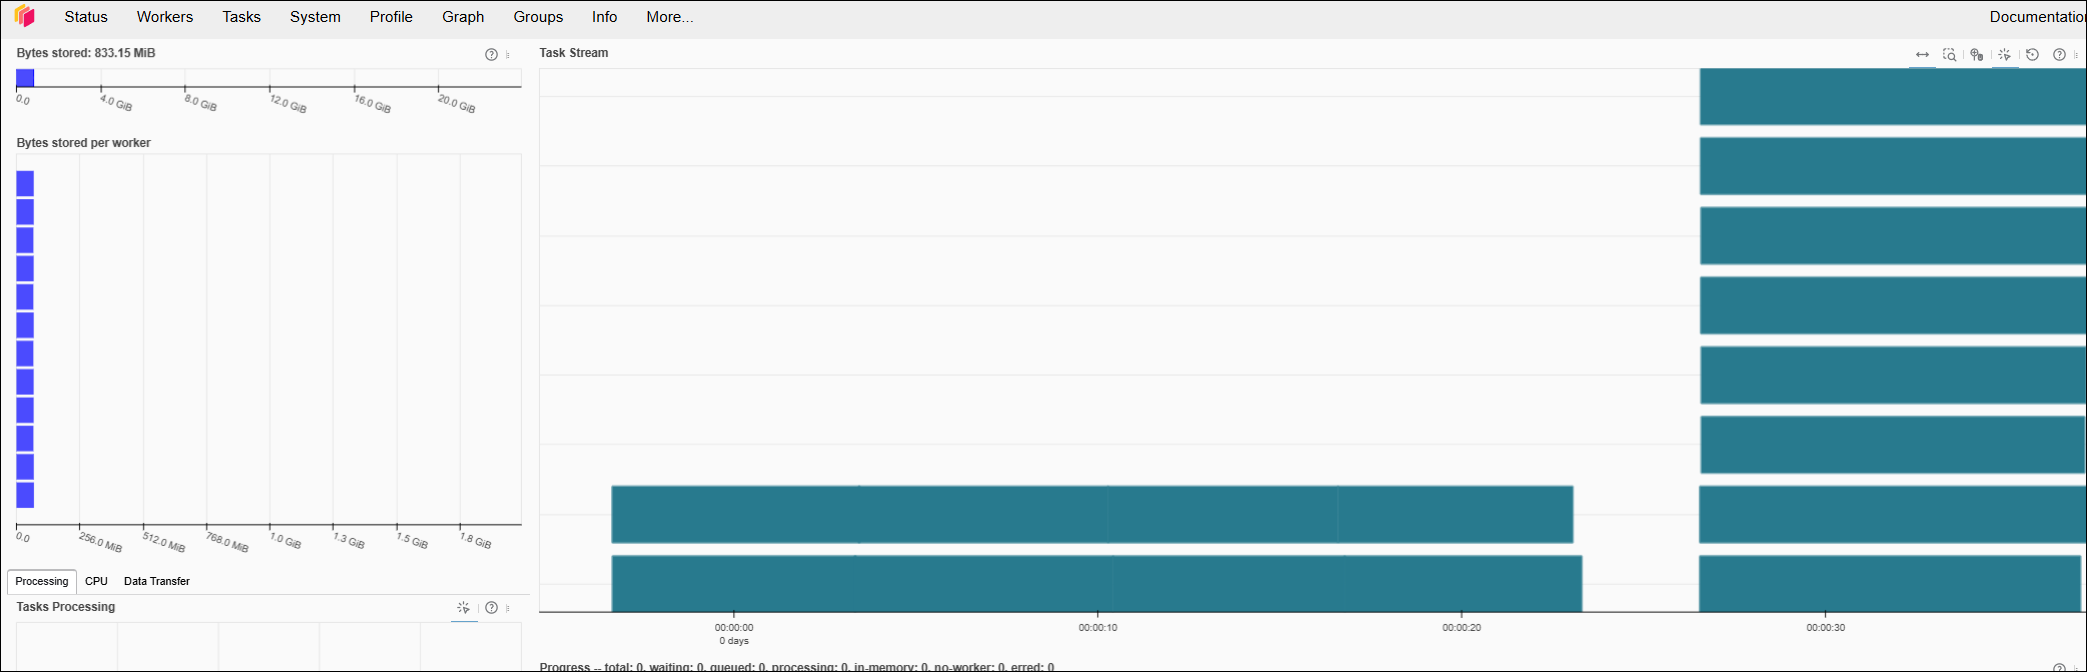

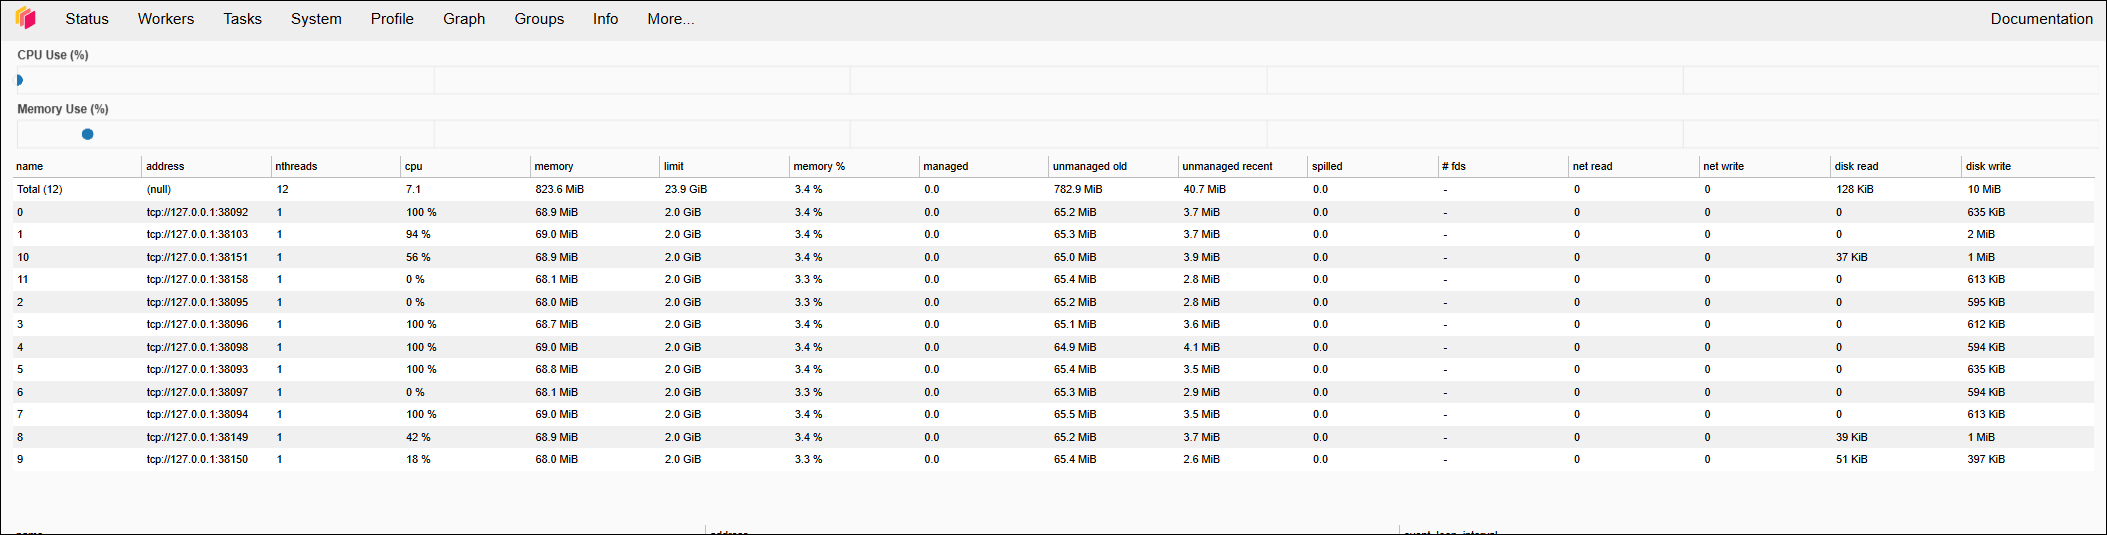

In [4]:
from IPython.display import Image, display
display(Image(filename="ex2_dask_2__vs_12_workers.png"))
display(Image(filename="ex2_dask_12_workers.png"))

**Exercise 3: Dependent Task Graphs**

In [11]:
import time, numpy as np, dask
from dask import delayed
from dask.distributed import Client, LocalCluster

# Each function sleeps so stages are visible in the dashboard Task Stream
@delayed
def generate(seed, n): 
    time.sleep(0.3)
    return np.random.default_rng(seed).standard_normal(n)

@delayed
def chunk_max(data): 
    time.sleep(0.2)
    return float(np.max(np.abs(data)))

@delayed
def global_max(maxima): 
    time.sleep(0.2)
    return max(maxima) # fan-in: waits for ALL chunk_max

@delayed
def normalise(data, g): 
    time.sleep(0.3)
    return data / g # fan-out: parallel once gmax ready

if __name__ == '__main__':
    cluster = LocalCluster(n_workers=4, threads_per_worker=1)
    client = Client(cluster); print(client.dashboard_link)
    
    chunks = [generate(i, 50_000) for i in range(8)] # Stage 1a
    print(chunks)

    maxima = [chunk_max(c) for c in chunks]          # Stage 1b
    gmax   = global_max(maxima)                      # Stage 2: fan-in
    normed = [normalise(c, gmax) for c in chunks]    # Stage 3: fan-out
    
    dask.visualize(*normed, filename='task_graph_pipeline.png')
    t0 = time.perf_counter()
    results = dask.compute(*normed)
    print(f"Wall time: {time.perf_counter()-t0:.2f} s")

    input('Press Enter to proceed...')

    client.close(); cluster.close()


c:\Users\Kim\miniforge3\envs\nsc2026\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40460 instead
  warnings.warn(


http://127.0.0.1:40460/status
[Delayed('generate-a6a004ae-0c11-47bf-8e7e-731f48e294cb'), Delayed('generate-4b109adf-3890-4c92-8e1d-ad1d0deb010e'), Delayed('generate-743d195c-b8d5-405d-8ecd-ad2d055897aa'), Delayed('generate-f89d3a0a-6730-487f-a6ca-e8cfe38a41ea'), Delayed('generate-7c86da15-a3d2-4b98-bc89-a1850b736223'), Delayed('generate-88716fe2-331e-425a-a8b7-5980237fa850'), Delayed('generate-017d58b7-55d2-4fea-9212-7ea75a5783ce'), Delayed('generate-705c9f86-d1ae-4b08-9832-445c654f8a32')]
Wall time: 2.01 s


**What to observe:**
* Task graph (task graph pipeline.png): does the hourglass shape match the three-stage structure? 

*Yes. The image below indicates the overall structure for the execution. At the bottom we see the parallel stage, where the generate function is called and generates each chunk. Subsequently, we also in parallel compute the local max chunk. All these local max values are fed to the global function to find the overall max chunk. Lastly, we normalize by dividing or normalising by the global max chunk.*

* Timing: how close to T∞ = TS1/nw + TS2 + TS3/nw ?

Theoretically based on the time sleeps and considering that we have 8 chunks, T∞ is
$$T_{S1} = \frac{(0.3 + 0.2)*8}{4} = \frac{(0.5*8)}{4}$$
$$T_{S2} = 0.2$$
$$T_{S3} = \frac{(0.3*8)}{4}$$
$$T_{\infty} = \frac{(0.5*8)}{4} + 0.2 + \frac{(0.3*8)}{4} = 1.8s$$

Based on the task stream, the task durations are very close to the sleep durations, so the result will also be very close to 1.8s

*  Identify the phases in the Task Stream

*The Task stream is indicted below. The first blue tasks indicates the generate calls. The green tasks denotes the chunk_max calls and the single yellow task is the global_max call. The last blue tasks denotes the normalise tasks.*

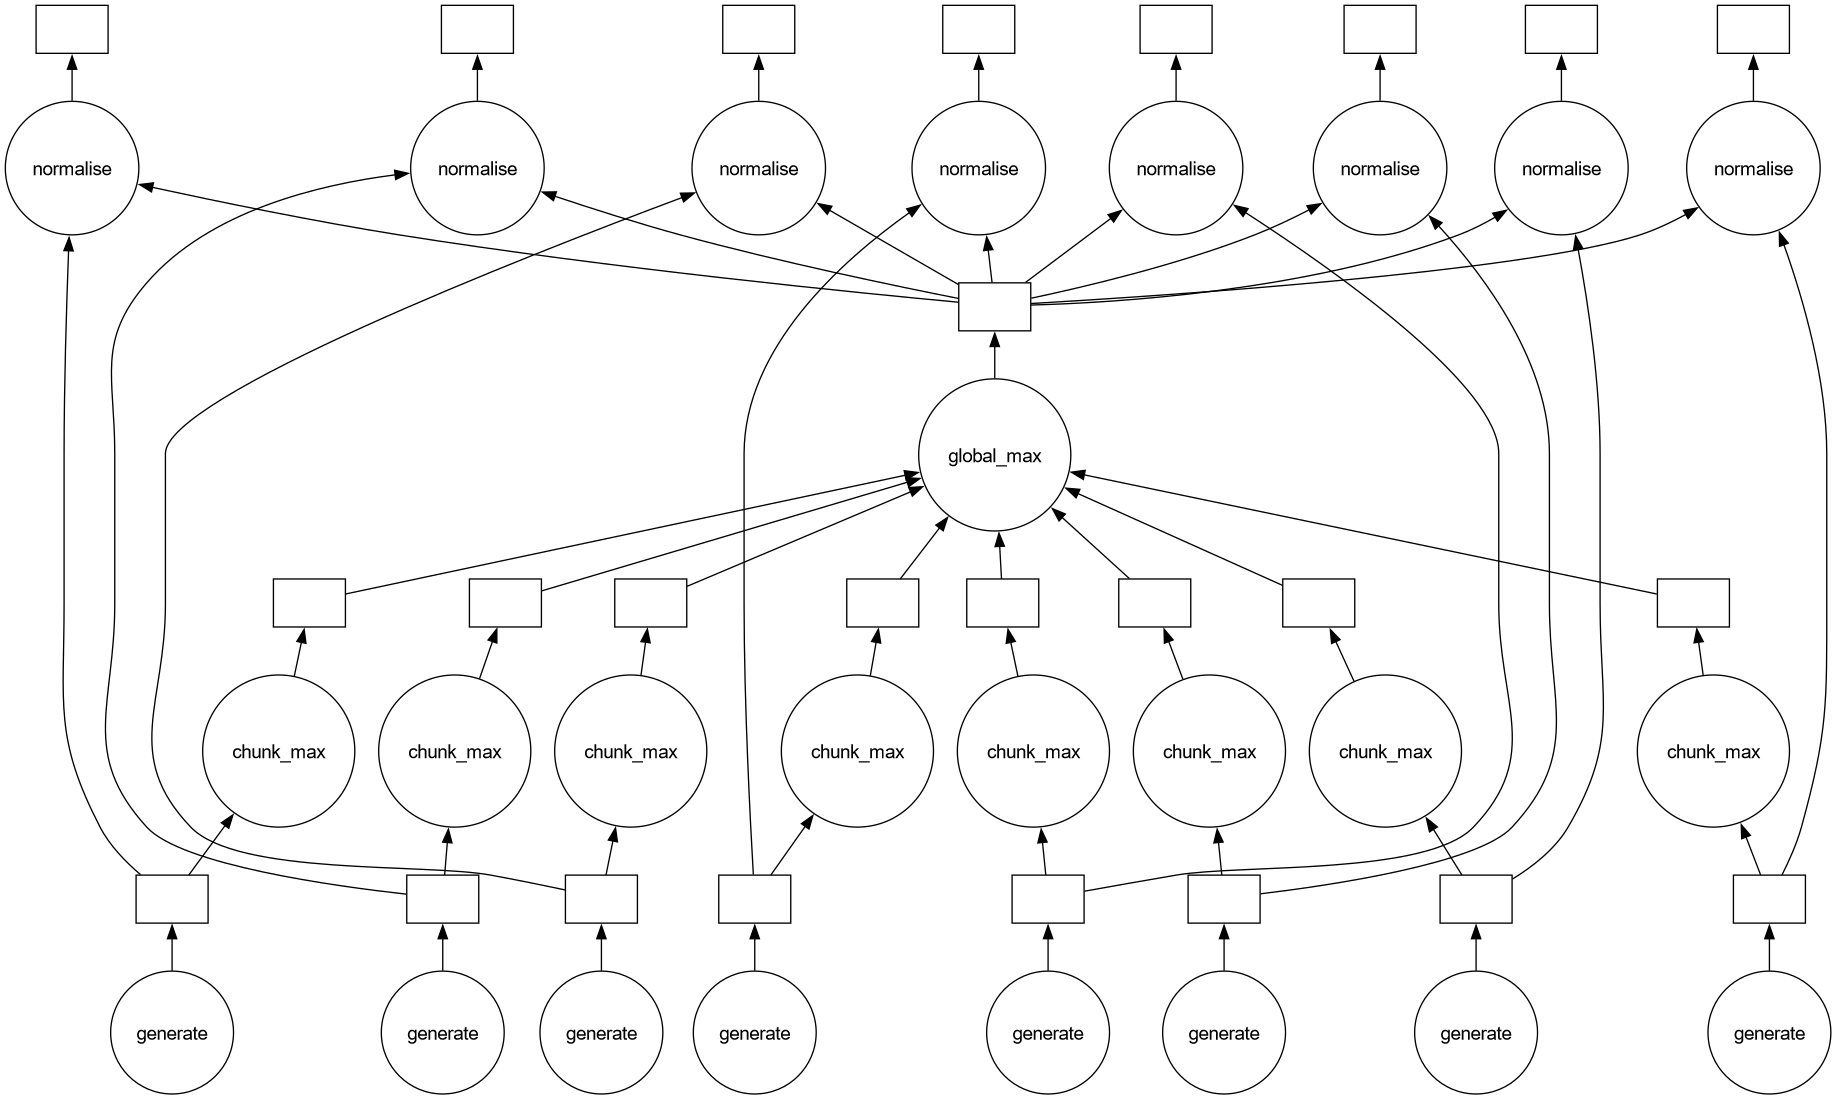

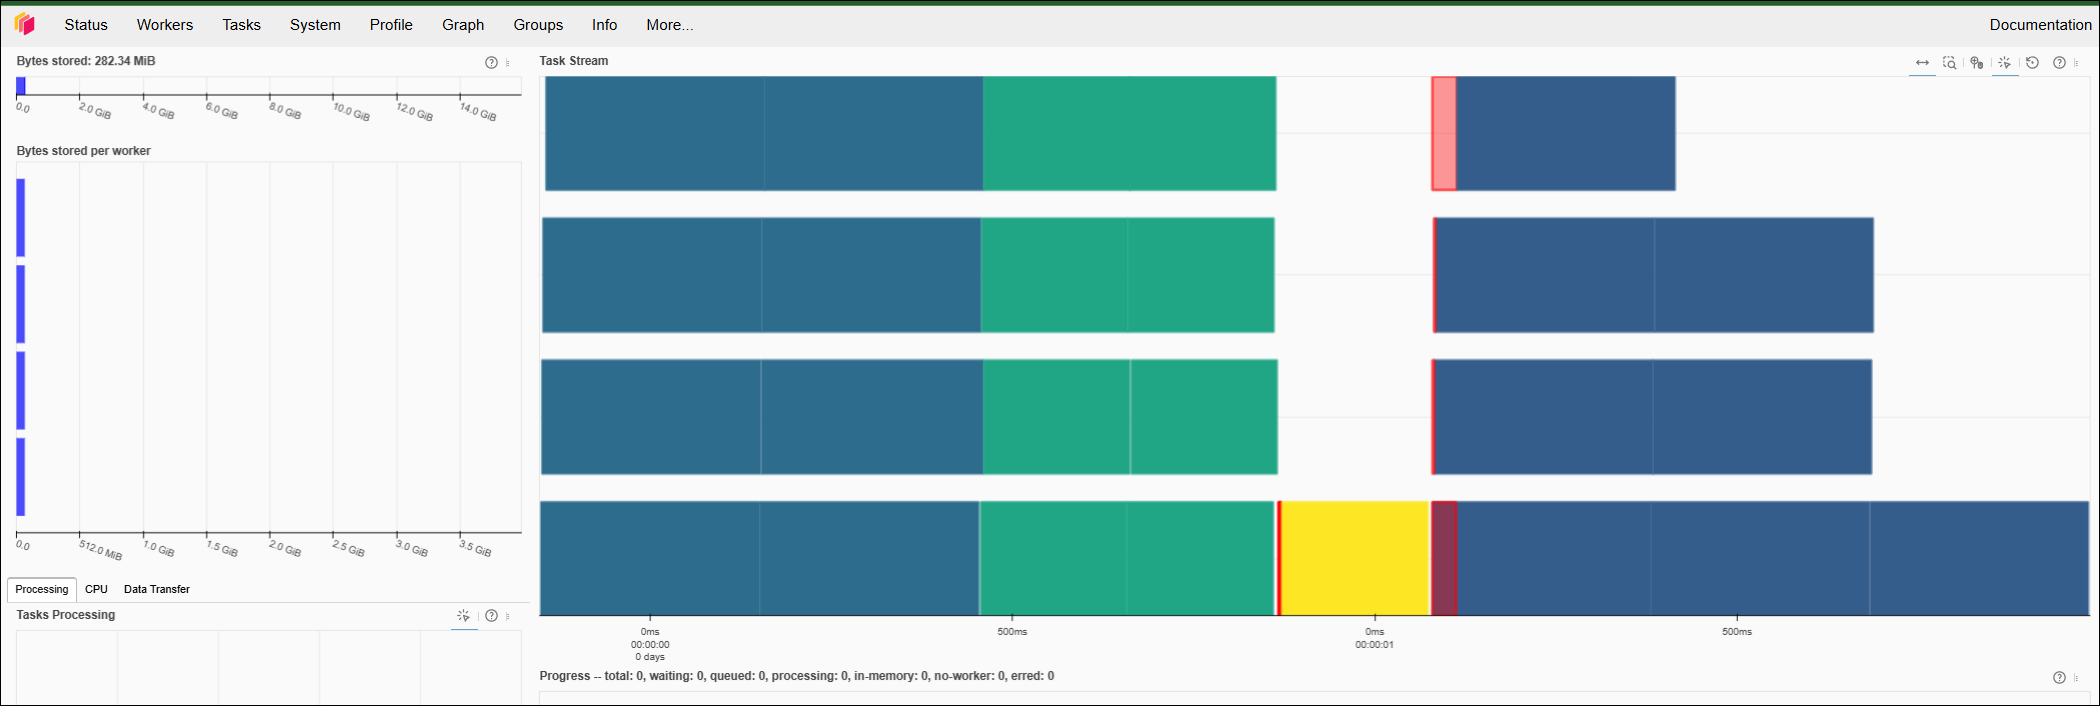

In [17]:
from IPython.display import Image, display
display(Image(filename="task_graph_pipeline.png", width=900))
display(Image(filename="ex3_dask.png", width=1000))

### Milestones

**Milestone 1: Dask Mandelbrot — Local**

In [1]:
from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, numpy as np, time, statistics 
from numba import njit, prange

@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

# mandelbrot_chunk: your @njit(cache=True) function from L04/L05
def mandelbrot_dask(N, x_min, x_max, y_min, y_max, max_iter=100, n_chunks=32):
    chunk_size = max(1, N // n_chunks)
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(delayed(mandelbrot_chunk)(row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)

if __name__ =='__main__':
    N, max_iter = 1024, 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25
    n_workers = 4
    cluster   = LocalCluster(n_workers=n_workers, threads_per_worker=1)
    client    = Client(cluster)
    client.run(lambda: mandelbrot_chunk(0, 8, 8, X_MIN, X_MAX, # warm up all workers
                                                Y_MIN, Y_MAX, 10))
    
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        result = mandelbrot_dask(N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
        times.append(time.perf_counter() - t0)

    print(f"Dask local(n_chunks=32):{statistics.median(times):.3f}s")
    client.close(); cluster.close()

Dask local(n_chunks=32):0.132s


**Milestone 2: Chunk Size Sweep**

Serial baseline walltime: 0.122s

n_chunks | walltime (s) |    vs 1x |  speedup |      lif
--------------------------------------------------------------------------------
       1 |    0.142 |    1.165 |    0.858 |    3.660
       2 |    0.084 |    0.691 |    1.447 |    1.764
       4 |    0.082 |    0.671 |    1.490 |    1.685
       6 |    0.079 |    0.648 |    1.544 |    1.591
       8 |    0.093 |    0.763 |    1.310 |    2.053
      10 |    0.073 |    0.597 |    1.675 |    1.389
      12 |    0.089 |    0.733 |    1.365 |    1.931
      16 |    0.085 |    0.700 |    1.428 |    1.801
      24 |    0.111 |    0.912 |    1.096 |    2.649
      32 |    0.132 |    1.088 |    0.919 |    3.352
      64 |    0.215 |    1.772 |    0.564 |    6.086
Optimal n_chunks: 10, walltime: 0.073, sp: 1.675, lif: 1.389
Min lif: 1.389 using n_chunks: 10, Min walltime: 0.073
Saved: /Users/kimnielsen/Library/CloudStorage/OneDrive-AalborgUniversitet/Git/aau-repos/2_semester/nsc-kim/dask_chunk_sweep.png


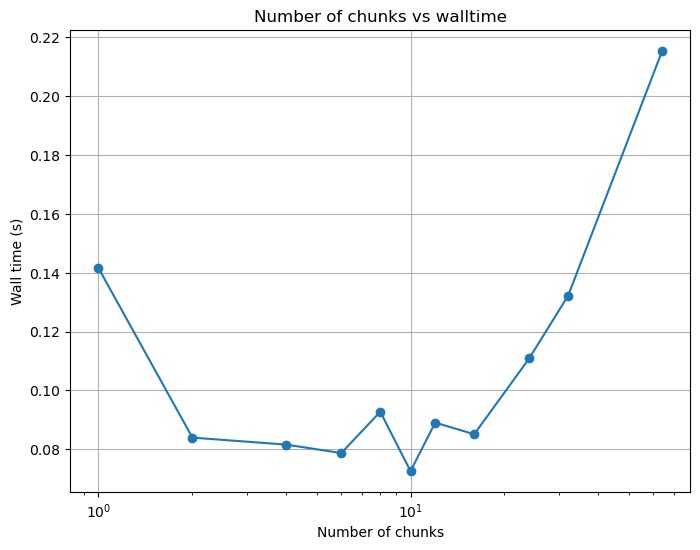

In [13]:
from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, numpy as np, time, statistics 
from numba import njit, prange
import matplotlib.pyplot as plt
from pathlib import Path

@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

def mandelbrot_dask(N, x_min, x_max, y_min, y_max, max_iter=100, n_chunks=32):
    chunk_size = max(1, N // n_chunks)
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(delayed(mandelbrot_chunk)(row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)

if __name__ =='__main__':
    results = []

    N, max_iter = 1024, 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25

    n_workers = 4
    cluster   = LocalCluster(n_workers=n_workers, threads_per_worker=1)
    client    = Client(cluster)

    # warm up all workers - make sure mandelbrot_chunk + mandelbrot_pixel have been compiled before benchmark below
    client.run(lambda: mandelbrot_chunk(0, 8, 8, X_MIN, X_MAX, Y_MIN, Y_MAX, 10))

    t0 = time.perf_counter()
    mandelbrot_chunk(0, N, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
    T1 = time.perf_counter() - t0

    print(f'Serial baseline walltime: {T1:.3f}s')

    # Sweep n chunks
    n_chunks_list = [1, 2, 4, 6, 8, 10, 12, 16, 24, 32, 64]
    for n_chunks in n_chunks_list:
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            result = mandelbrot_dask(N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter, n_chunks)
            times.append(time.perf_counter() - t0)
        
        # Compute metrics
        Tp    = statistics.median(times)
        sp    = T1 / Tp
        vs_1x = Tp / T1
        lif   = (n_workers * Tp / T1) -1

        # Save results
        new_result = {
            'n_chunks' : n_chunks,
            'walltime' : Tp,
            'sp' : sp,
            'vs_1x' : vs_1x,
            'lif' : lif,
        }
        results.append(new_result)
    
    client.close(); cluster.close()
    
    # Print results...
    print()
    print(f"{'n_chunks':>8} | {'walltime (s)':>10} | {'vs 1x':>8} | {'speedup':>8} | {'lif':>8}")
    print('-'*80)

    for r in results:
        print(f"{r['n_chunks']:>8} | {r['walltime']:>8.3f} | {r['vs_1x']:>8.3f} | {r['sp']:>8.3f} | {r['lif']:>8.3f}")

    # Find optimal chunk size:
    t_min_obj    = min(results, key=lambda d: d['walltime']) # find object with minimum walltime
    optimal_chunks   = t_min_obj['n_chunks']
    optimal_sp       = t_min_obj['sp']
    optimal_lif      = t_min_obj['lif']
    optimal_walltime = t_min_obj['walltime']
    print(f'Optimal n_chunks: {optimal_chunks}, walltime: {optimal_walltime:.3f}, sp: {optimal_sp:.3f}, lif: {optimal_lif:.3f}')
    
    lif_min_obj  = min(results, key=lambda d: d['lif']) # find object with minimum lif
    print(f"Min lif: {lif_min_obj['lif']:.3f} using n_chunks: {lif_min_obj['n_chunks']}, Min walltime: {lif_min_obj['walltime']:.3f}")

    # Plotting
    n_chunks  = [ r['n_chunks'] for r in results ]
    walltimes = [ r['walltime'] for r in results ]
    
    fig, ax = plt.subplots( figsize=(8,6) )
    ax.plot( n_chunks, walltimes, marker='o' )
    ax.set_xscale('log')
    ax.set_xlabel('Number of chunks')
    ax.set_ylabel('Wall time (s)')
    ax.set_title('Number of chunks vs walltime')
    ax.grid()

    out = Path.cwd() / 'dask_chunk_sweep.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')

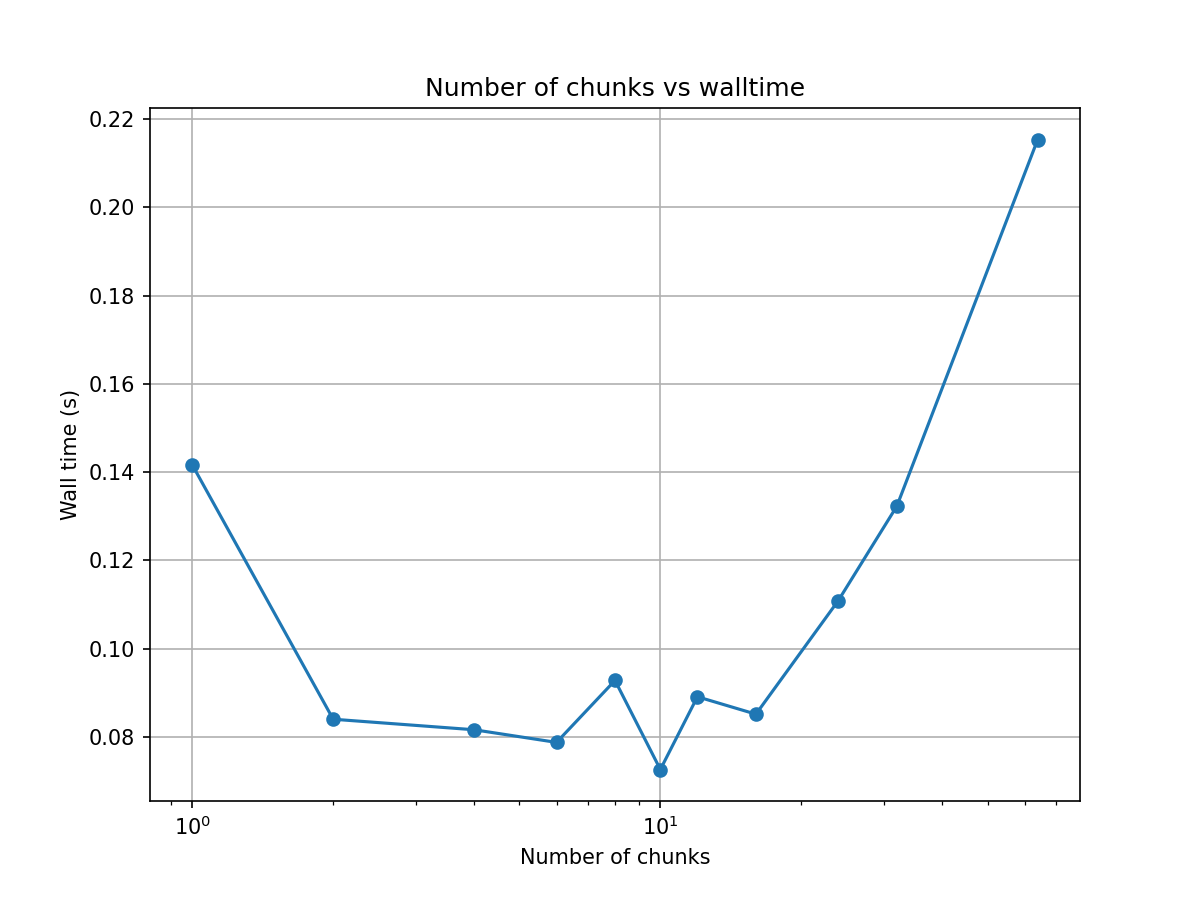

In [14]:
from IPython.display import Image, display
display(Image(filename="dask_chunk_sweep.png", width=600))

**Optional Early exit**

In [ ]:
from dask import delayed
from dask.distributed import Client, LocalCluster
import dask, numpy as np, time, statistics 
from numba import njit, prange
import matplotlib.pyplot as plt
from pathlib import Path

@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

@njit(cache=True)
def mandelbrot_chunk_early_exit(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> np.ndarray:
    
    rows           = row_end - row_start
    mandelbrot_set = np.full( shape=(rows, N), fill_value=max_iter, dtype=np.int32)
    dx             = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy             = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis
    z_real         = np.zeros((rows, N))
    z_imag         = np.zeros((rows, N))
    active         = np.ones( (rows, N), dtype=np.bool_ ) # array to keep track of who is still working
    
    for n in range(max_iter):
        any_active = False
        
        for row in range(rows):
            c_imag = y_min + (row + row_start) * dy
            for column in range(N):
                if not active[row, column]:
                    continue
                
                any_active = True
                
                zr    = z_real[row,column]
                zi    = z_imag[row,column]
                zr_sq = zr * zr
                zi_sq = zi * zi
                
                if (zr_sq + zi_sq) > 4.0:
                    mandelbrot_set[row,column] = n
                    active[row,column] = False
                else:
                    z_imag[row,column] = 2.0*zr*zi + c_imag
                    z_real[row,column] = zr_sq - zi_sq + (x_min + column*dx)
        if not any_active:
            break # early exit here
    
    return mandelbrot_set

def mandelbrot_dask(N, x_min, x_max, y_min, y_max, max_iter=100, n_chunks=32):
    chunk_size = max(1, N // n_chunks)
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(delayed(mandelbrot_chunk_early_exit)(row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)

if __name__ =='__main__':
    results = []

    N, max_iter = 1024, 100
    X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25

    n_workers = 4
    cluster   = LocalCluster(n_workers=n_workers, threads_per_worker=1)
    client    = Client(cluster)

    # warm up all workers - make sure mandelbrot_chunk + mandelbrot_pixel have been compiled before benchmark below
    client.run(lambda: mandelbrot_chunk_early_exit(0, 8, 8, X_MIN, X_MAX, Y_MIN, Y_MAX, 10))

    t0 = time.perf_counter()
    mandelbrot_chunk_early_exit(0, N, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
    T1 = time.perf_counter() - t0

    print(f'Serial baseline walltime: {T1:.3f}s')

    # Sweep n chunks
    n_chunks_list = [1, 2, 4, 6, 8, 10, 12, 16, 24, 32, 64]
    for n_chunks in n_chunks_list:
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            result = mandelbrot_dask(N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter, n_chunks)
            times.append(time.perf_counter() - t0)
        
        # Compute metrics
        Tp    = statistics.median(times)
        sp    = T1 / Tp
        vs_1x = Tp / T1
        lif   = (n_workers * Tp / T1) -1

        # Save results
        new_result = {
            'n_chunks' : n_chunks,
            'walltime' : Tp,
            'sp' : sp,
            'vs_1x' : vs_1x,
            'lif' : lif,
        }
        results.append(new_result)
    
    client.close(); cluster.close()
    
    # Print results...
    print()
    print(f"{'n_chunks':>8} | {'walltime (s)':>10} | {'vs 1x':>8} | {'speedup':>8} | {'lif':>8}")
    print('-'*80)

    for r in results:
        print(f"{r['n_chunks']:>8} | {r['walltime']:>8.3f} | {r['vs_1x']:>8.3f} | {r['sp']:>8.3f} | {r['lif']:>8.3f}")

    # Find optimal chunk size:
    t_min_obj    = min(results, key=lambda d: d['walltime']) # find object with minimum walltime
    optimal_chunks   = t_min_obj['n_chunks']
    optimal_sp       = t_min_obj['sp']
    optimal_lif      = t_min_obj['lif']
    optimal_walltime = t_min_obj['walltime']
    print(f'Optimal n_chunks: {optimal_chunks}, walltime: {optimal_walltime:.3f}, sp: {optimal_sp:.3f}, lif: {optimal_lif:.3f}')
    
    lif_min_obj  = min(results, key=lambda d: d['lif']) # find object with minimum lif
    print(f"Min lif: {lif_min_obj['lif']:.3f} using n_chunks: {lif_min_obj['n_chunks']}, Min walltime: {lif_min_obj['walltime']:.3f}")

*No Early Exit*

```
Serial baseline walltime: 0.438s

n_chunks | walltime (s) |    vs 1x |  speedup |      lif
--------------------------------------------------------------------------------
       1 |    0.106 |    0.241 |    4.149 |   -0.036
       2 |    0.067 |    0.152 |    6.567 |   -0.391
       4 |    0.063 |    0.143 |    6.991 |   -0.428
       6 |    0.074 |    0.170 |    5.886 |   -0.320
       8 |    0.070 |    0.159 |    6.271 |   -0.362
      10 |    0.070 |    0.159 |    6.270 |   -0.362
      12 |    0.067 |    0.152 |    6.558 |   -0.390
      16 |    0.067 |    0.154 |    6.510 |   -0.386
      24 |    0.079 |    0.181 |    5.533 |   -0.277
      32 |    0.088 |    0.201 |    4.985 |   -0.198
      64 |    0.138 |    0.315 |    3.171 |    0.261
Optimal n_chunks: 4, walltime: 0.063, sp: 6.991, lif: -0.428
```

*With Early Exit*

```
Serial baseline walltime: 1.088s

n_chunks | walltime (s) |    vs 1x |  speedup |      lif
--------------------------------------------------------------------------------
       1 |    0.152 |    0.140 |    7.150 |   -0.441
       2 |    0.083 |    0.077 |   13.048 |   -0.693
       4 |    0.072 |    0.066 |   15.043 |   -0.734
       6 |    0.074 |    0.068 |   14.638 |   -0.727
       8 |    0.079 |    0.072 |   13.801 |   -0.710
      10 |    0.075 |    0.069 |   14.580 |   -0.726
      12 |    0.085 |    0.078 |   12.832 |   -0.688
      16 |    0.077 |    0.070 |   14.202 |   -0.718
      24 |    0.092 |    0.085 |   11.823 |   -0.662
      32 |    0.118 |    0.108 |    9.218 |   -0.566
      64 |    0.153 |    0.140 |    7.121 |   -0.438
Optimal n_chunks: 4, walltime: 0.072, sp: 15.043, lif: -0.734
Min lif: -0.734 using n_chunks: 4, Min walltime: 0.072
```

Although early exit was added, it did not really improve the performance. This could be due to most of the pixels diverge early during the iteration of pixels and the added check of active pixels provides additional overhead, leading the early exit method to be slower.

**Milestone 3: Full Benchmark — All Implementations**

*Speedup table*

**Benchmark Table (based on results from MP1 report and chunked parallel Mandelbrot with optimal chunk size)**
| Version   | Time | Speedup |
| -------- | ------- | ------- |
| Naive    | 10.260s | 1x      |
| Numpy    | 0.870s  | 11.8x   |
| Numba    | 0.075s  | 136.9x  |
| Numba + multiprocessing | 0.028s  | 366.4x  |
| Dask Local | 0.073s  | 140.5x  |

**Reflection questions**

How does Dask local compare to multiprocessing at the same worker count?

*Using the same amount of workers, I was able to obtain higher speedup using multiprocessing. I achieved 366.4 times speedup using multiprocessing and 140.5 times speedup using Dask local. I suspect the lower performance with Dask is due to additional per-task scheduling overhead ($\alpha$). I observed that the optimal number of chunks using Dask was way lower compared to the optimal number of chunks using multiprocessing. The optimal number of chunks for dask is 6 chunks, where the optimal number of chunks for multiprocessing was 64 chunks. This seems to indicate that Dask performs better with less tasks that are large in size. The optimal conditions for multiprocessing is the opposite as multiprocessing seems to work more efficient for many small tasks*

What does the overhead difference tell you about when to choose each tool?
*As stated before, the overhead seems to indicate that Dask is better suited for tasks that each requires a more substantial amount of work. On the other hand, multiprocessing has less overhead per task and is therefore more efficient at handling many small tasks. In other words, I would choose Dask if I have a select few large tasks and multiprocessing if I have many small tasks*

---

# Dask on Strato Cluster

### Exercises & Milestone

**Exericse 1: Set Up a Strato Dask Cluster**

In [ ]:
# Code intended to run on a strato instance

from dask.distributed import Client

if __name__ =='__main__':
    dask_url = "tcp://10.92.1.239:8786"    
    print(f'Connecting to: {dask_url}')
    client = Client(dask_url)
    versions = client.run(lambda: __import__('dask').__version__)
    print(versions)   # all dask version must be identical

**Output from Python script run on Strato instance**

```sh
(nsc) ubuntu@kim-ubuntu-2004-2:~$ python3 test_dask.py 
Connecting to: tcp://10.92.1.239:8786
{'tcp://10.92.1.100:37449': '2026.3.0', 'tcp://10.92.1.100:42897': '2026.3.0'}
```

The Dask version is *2026.3.0* and is identical on all instances based on the output above.

**Milestone 1: What to Benchmark**

In [ ]:
# ----------------------------------------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------------------------------------
from numba import njit
from pathlib import Path
from dask import delayed
from dask.distributed import Client
import dask, numpy as np, time, statistics 
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------------------
# Constants
# ----------------------------------------------------------------------------------------------------
N        = 16384

max_iter = 100
X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25
# max_iter = 1000
# X_MIN, X_MAX, Y_MIN, Y_MAX = -0.75, -0.74, 0.099, 0.109

n_workers = 2
dask_url = "tcp://10.92.1.128:8786"

# ----------------------------------------------------------------------------------------------------
# Methods
# ----------------------------------------------------------------------------------------------------
@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter) -> None:
    """
    Finds iteration count for a single point in the complex grid.
    """
    z_real = z_imag = 0.0
    
    for n in range(max_iter):
        z_real_sq = z_real * z_real
        z_imag_sq = z_imag * z_imag
        if ( z_real_sq + z_imag_sq ) > 4: return n
        z_imag = 2.0 * z_real*z_imag + c_imag
        z_real = z_real_sq - z_imag_sq + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> None:
    """
    Computes pixel coordinates from index + bounds. We take no arrays as input.
    Returns a (row_end - row_start)xN int32 numpy array
    """
    mandelbrot_set = np.empty( (row_end - row_start, N), dtype=np.int32)
    dx = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis

    # Loop over all grid complex values and check for divergence with mandelbrot function
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for column in range(N):
            mandelbrot_set[r, column] = mandelbrot_pixel(x_min + column*dx, c_imag, max_iter)
    return mandelbrot_set

@njit(cache=True)
def mandelbrot_chunk_early_exit(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter) -> np.ndarray:
    
    rows           = row_end - row_start
    mandelbrot_set = np.full( shape=(rows, N), fill_value=max_iter, dtype=np.int32)
    dx             = ( x_max - x_min ) / N # Compute normalization factor for real axis
    dy             = ( y_max - y_min ) / N # Compute normalization factor for imaginary axis
    z_real         = np.zeros((rows, N))
    z_imag         = np.zeros((rows, N))
    active         = np.ones( (rows, N), dtype=np.bool_ ) # array to keep track of who is still working
    
    for n in range(max_iter):
        any_active = False
        
        for row in range(rows):
            c_imag = y_min + (row + row_start) * dy
            for column in range(N):
                if not active[row, column]:
                    continue
                
                any_active = True
                
                zr    = z_real[row,column]
                zi    = z_imag[row,column]
                zr_sq = zr * zr
                zi_sq = zi * zi
                
                if (zr_sq + zi_sq) > 4.0:
                    mandelbrot_set[row,column] = n
                    active[row,column] = False
                else:
                    z_imag[row,column] = 2.0*zr*zi + c_imag
                    z_real[row,column] = zr_sq - zi_sq + (x_min + column*dx)
        if not any_active:
            break # early exit here
    
    return mandelbrot_set

def mandelbrot_dask(N, x_min, x_max, y_min, y_max, max_iter=100, n_chunks=32) -> np.ndarray:
    """
    Call mandelbrot_chunk method through dask.
    Args:
        N (_type_): _description_
        x_min (_type_): _description_
        x_max (_type_): _description_
        y_min (_type_): _description_
        y_max (_type_): _description_
        max_iter (int, optional): _description_. Defaults to 100.
        n_chunks (int, optional): _description_. Defaults to 32.

    Returns:
        _type_: _description_
    """
    chunk_size = max(1, N // n_chunks)
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        # tasks.append(delayed(mandelbrot_chunk)(row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        tasks.append(delayed(mandelbrot_chunk_early_exit)(row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)


# ----------------------------------------------------------------------------------------------------
# Main region
# ----------------------------------------------------------------------------------------------------
if __name__ =='__main__':
    results = []
    
    print(f'Using: {n_workers} workers')
    print(f'Connecting to: {dask_url}')
    client = Client(dask_url)
    versions = client.run(lambda: __import__('dask').__version__)
    print(versions) # all dask version must be identical

    # warm up all workers - make sure mandelbrot_chunk + mandelbrot_pixel have been compiled before benchmark below
    # client.run(lambda: mandelbrot_chunk(0, 8, 8, X_MIN, X_MAX, Y_MIN, Y_MAX, 10))
    client.run(lambda: mandelbrot_chunk_early_exit(0, 8, 8, X_MIN, X_MAX, Y_MIN, Y_MAX, 10))
    
    # Measure serial mandelbrot walltime and use as baseline
    t0 = time.perf_counter()
    # mandelbrot_chunk(0, N, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
    mandelbrot_chunk_early_exit(0, N, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
    T1 = time.perf_counter() - t0
    print(f'Serial baseline walltime: {T1:.3f}s')

    # Sweep n chunks
    n_chunks_list = [1, 2, 4, 6, 8, 10, 12, 16, 24, 32, 64, 128, 256]
    # n_chunks_list = [2]
    for n_chunks in n_chunks_list:
        # print(f'Chunks: {n_chunks}')
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            result = mandelbrot_dask(N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter, n_chunks)
            times.append(time.perf_counter() - t0)
        
        # Compute metrics
        Tp    = statistics.median(times)
        sp    = T1 / Tp
        vs_1x = Tp / T1
        lif   = (n_workers * Tp / T1) - 1

        # Save results & add to result list
        new_result = {
            'n_chunks' : n_chunks,
            'walltime' : Tp,
            'sp'       : sp,
            'vs_1x'    : vs_1x,
            'lif'      : lif,
        }
        results.append(new_result)
    client.close() # Close dask client connection
    
    # ======================================== Results handling ========================================
    # Print results from sweep experiment
    print()
    print(f"{'n_chunks':>8} | {'walltime (s)':>10} | {'vs 1x':>8} | {'speedup':>8} | {'lif':>8}")
    print('-'*80)
    
    for r in results:
        print(f"{r['n_chunks']:>8} | {r['walltime']:>8.3f} | {r['vs_1x']:>8.3f} | {r['sp']:>8.3f} | {r['lif']:>8.3f}")
    
    # Find minimum metrics & find optimal chunk size:
    t_min_obj    = min(results, key=lambda d: d['walltime']) # find object with minimum walltime
    optimal_chunks   = t_min_obj['n_chunks']
    optimal_sp       = t_min_obj['sp']
    optimal_lif      = t_min_obj['lif']
    optimal_walltime = t_min_obj['walltime']
    print(f'Optimal n_chunks: {optimal_chunks}, walltime: {optimal_walltime:.3f}, sp: {optimal_sp:.3f}, lif: {optimal_lif:.3f}')
    
    # find object with minimum lif
    lif_min_obj  = min(results, key=lambda d: d['lif'])
    print(f"Min lif: {lif_min_obj['lif']:.3f} using n_chunks: {lif_min_obj['n_chunks']}, Min walltime: {lif_min_obj['walltime']:.3f}")
    
    # Plotting
    n_chunks  = [ r['n_chunks'] for r in results ]
    walltimes = [ r['walltime'] for r in results ]
    
    fig, ax = plt.subplots( figsize=(8,6) )
    ax.plot( n_chunks, walltimes, marker='o' )
    ax.set_xscale('log')
    ax.set_xlabel('Number of chunks')
    ax.set_ylabel('Wall time (s)')
    ax.set_title('Number of chunks vs walltime')
    ax.grid()
    
    # Save figure
    out = Path.cwd() / 'dask_chunk_sweep.png'
    fig.savefig(out, dpi=150)
    print(f'Saved: {out}')


**Experiment 1: Chunk size sweep**

This experiment was carried out with 2 workers and grid size of 4096 by 4096 pixels.
Additionally, the applied number of chunks for this experiment were: 
1, 2, 4, 6, 8, 10, 12, 16, 24, 32, 64, 128, 256

*Output using N=4096, 2 workers*

Serial baseline walltime: 2.095s

Optimal n_chunks: 64, walltime: 0.979, sp: 2.139, lif: -0.065

Min lif: -0.065 using n_chunks: 64, Min walltime: 0.979

| n_chunks | walltime (s) |    vs 1x |  speedup | lif |
|-------|-------|-------|-------|-------|
|       1 |    1.968 |    0.940 |    1.064 |    0.879 |
|       2 |    1.213 |    0.579 |    1.727 |    0.158 |
|       4 |    1.178 |    0.563 |    1.778 |    0.125 |
|       6 |    1.203 |    0.574 |    1.742 |    0.148 |
|       8 |    1.341 |    0.640 |    1.562 |    0.281 |
|      10 |    1.171 |    0.559 |    1.789 |    0.118 |
|      12 |    1.154 |    0.551 |    1.814 |    0.102 |
|      16 |    1.089 |    0.520 |    1.924 |    0.039 |
|      24 |    1.027 |    0.490 |    2.040 |   -0.019 |
|      32 |    0.992 |    0.474 |    2.111 |   -0.052 |
|      64 |    0.979 |    0.468 |    2.139 |   -0.065 |
|     128 |    1.058 |    0.505 |    1.980 |    0.010 |
|     256 |    1.409 |    0.673 |    1.486 |    0.346 |

Based on the results above, the optimal number of chunks lies at 64 chunks leading to a walltime of 0.979 seconds.
Considering 64 chunks as the optimal number of chunks, the chunk size in this case is: $\frac{4096}{64}=64$

In the L06 milestone 2 experiment using a Dask local cluster, the execution was much faster. The walltime was 0.073 seconds using 10 number of chunks.
However, this comparison does not make sense with distributed Dask experiment since it was carried out with 4096 by 4096 grid size. The L06 milestone 2 experiment was carried out with a 4 times smaller grid size, so naturally the execution will be faster.

**Experiment 2: Worker scaling**

Two experiments were carried out. One with grid size of 4096x4096 and another using 16384x16384.
I chose not to just freeze the optimal number of chunks, so I could compare with multiple number of chunks.
The optimal number of chunks is of course still includes in the tables below.
One sidenote to add, for the experiments with 16384x16384, I chose to remove the 128 and 256 number of chunks, as this repeatedly killed the Python program.

*Experiment using N=4096, workers=4, max_iter=100*

Serial baseline walltime: 2.862s

Optimal n_chunks: 64, walltime: 0.588, sp: 4.869, lif: -0.178

Min lif: -0.178 using n_chunks: 64, Min walltime: 0.588

|n_chunks | walltime (s) |    vs 1x |  speedup | lif |
|-------|-------|-------|-------|-------|
|       1 |    1.893 |    0.661 |    1.512 |    1.645 |
|       2 |    1.043 |    0.364 |    2.745 |    0.457 |
|       4 |    0.761 |    0.266 |    3.759 |    0.064 |
|       6 |    1.017 |    0.356 |    2.813 |    0.422 |
|       8 |    0.760 |    0.265 |    3.768 |    0.062 |
|      10 |    0.687 |    0.240 |    4.168 |   -0.040 |
|      12 |    0.734 |    0.256 |    3.899 |    0.026 |
|      16 |    0.603 |    0.211 |    4.748 |   -0.158 |
|      24 |    0.633 |    0.221 |    4.522 |   -0.115 |
|      32 |    0.588 |    0.206 |    4.864 |   -0.178 |
|      64 |    0.588 |    0.205 |    4.869 |   -0.178 |
|     128 |    0.678 |    0.237 |    4.219 |   -0.052 |
|     256 |    0.744 |    0.260 |    3.848 |    0.039 |


*Experiment using N=16384, workers=2, max_iter=100*

Serial baseline walltime: 24.418s

Optimal n_chunks: 64, walltime: 12.268, sp: 1.990, lif: 0.005

Min lif: 0.005 using n_chunks: 64, Min walltime: 12.268

n_chunks | walltime (s) |    vs 1x |  speedup | lif |
|-------|-------|-------|-------|-------|
|       1 |   22.169 |    0.908 |    1.101 |    0.816 |
|       2 |   12.443 |    0.510 |    1.962 |    0.019 |
|       4 |   19.426 |    0.796 |    1.257 |    0.591 |
|       6 |   12.861 |    0.527 |    1.899 |    0.053 |
|       8 |   13.932 |    0.571 |    1.753 |    0.141 |
|      10 |   14.243 |    0.583 |    1.714 |    0.167 |
|      12 |   13.956 |    0.572 |    1.750 |    0.143 |
|      16 |   12.378 |    0.507 |    1.973 |    0.014 |
|      24 |   12.325 |    0.505 |    1.981 |    0.010 |
|      32 |   12.363 |    0.506 |    1.975 |    0.013 |
|      64 |   12.268 |    0.502 |    1.990 |    0.005 |

*Experiment using N=16384, workers=4, max_iter=100*

*Output using N=16384, 4 workers*

Serial baseline walltime: 24.197s

Optimal n_chunks: 24, walltime: 9.111, sp: 2.656, lif: 0.506

Min lif: 0.506 using n_chunks: 24, Min walltime: 9.111

n_chunks | walltime (s) |    vs 1x |  speedup | lif |
|-------|-------|-------|-------|-------|
|       1 |   23.733 |    0.981 |    1.020 |    2.923 |
|       2 |   12.700 |    0.525 |    1.905 |    1.099 |
|       4 |   12.913 |    0.534 |    1.874 |    1.135 |
|       6 |   12.407 |    0.513 |    1.950 |    1.051 |
|       8 |   10.701 |    0.442 |    2.261 |    0.769 |
|      10 |   10.381 |    0.429 |    2.331 |    0.716 |
|      12 |   10.698 |    0.442 |    2.262 |    0.769 |
|      16 |    9.680 |    0.400 |    2.500 |    0.600 |
|      24 |    9.111 |    0.377 |    2.656 |    0.506 |
|      32 |    9.996 |    0.413 |    2.421 |    0.652 |
|      64 |    9.128 |    0.377 |    2.651 |    0.509 |

Based on the results above for 4096x4096, there seems to be a somewhat linear scaling of the wall times decreasing and speedups increasing, as we increase the amount of chunks. The tables above also indicate that using 4 workers is faster than using 2 workers.

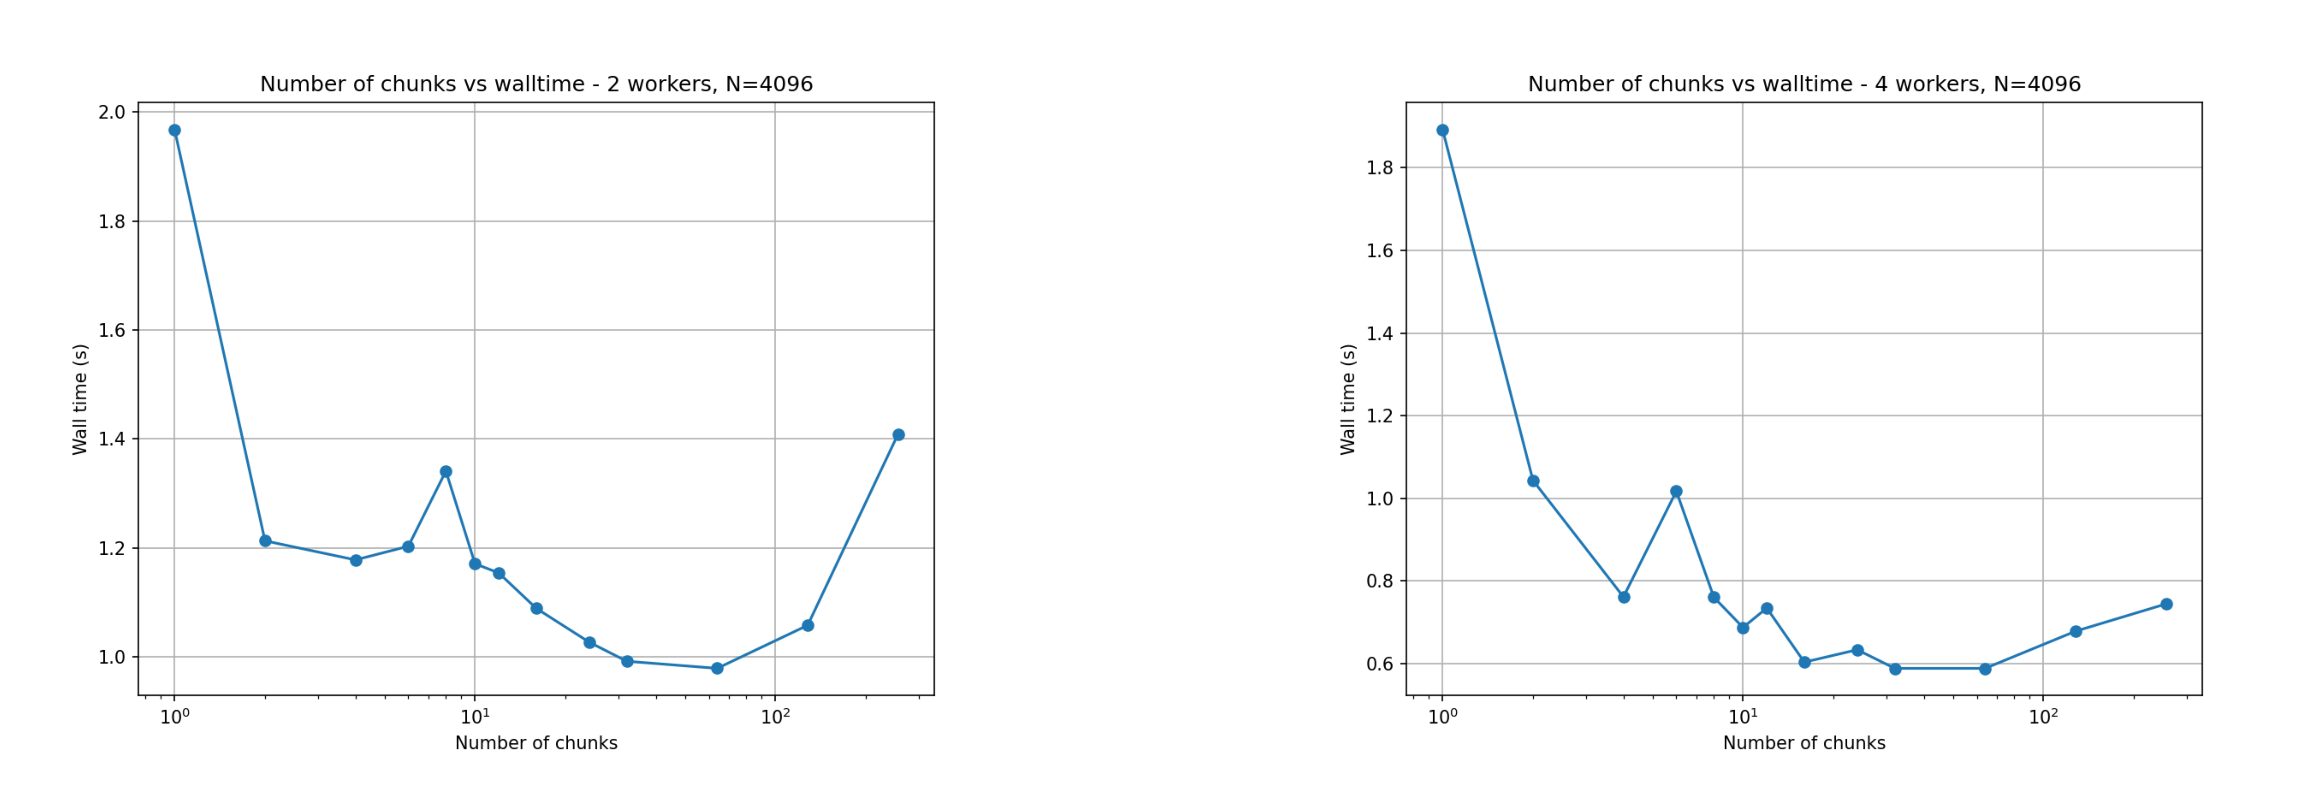

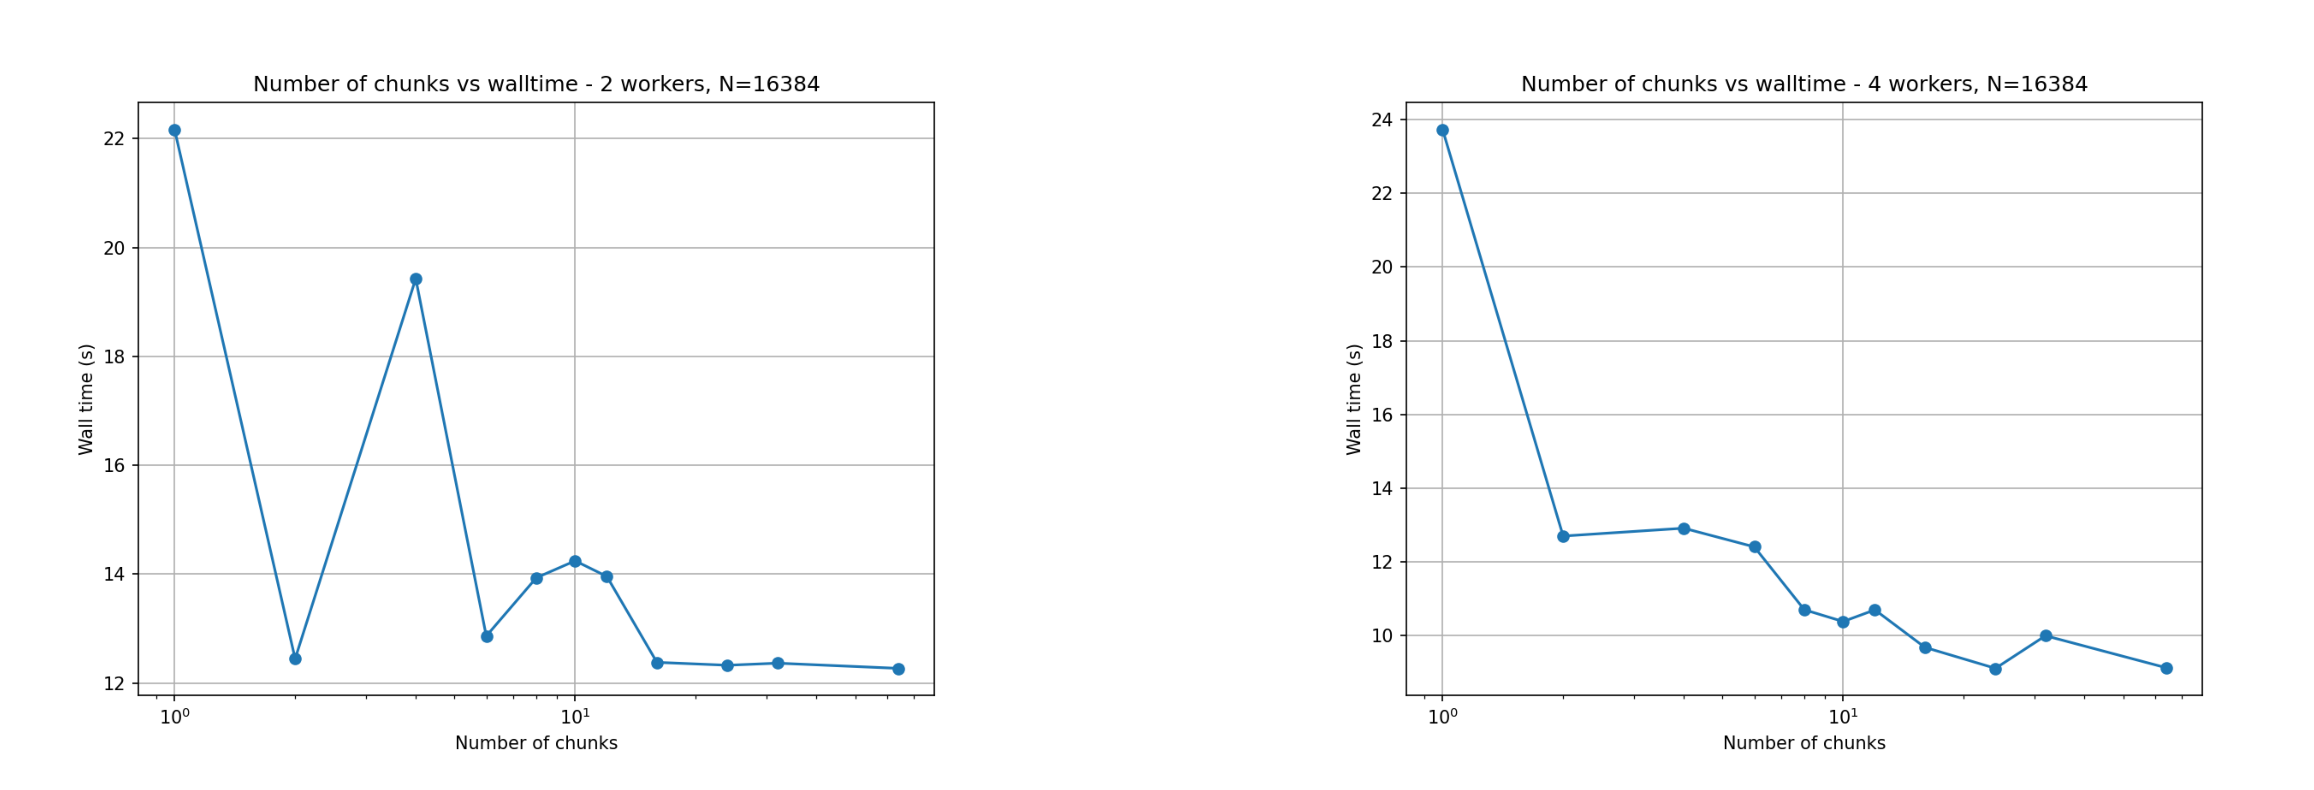

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('dask_chunk_sweep_2_workers_4096.png')
img2 = mpimg.imread('dask_chunk_sweep_4_workers_4096.png')
img3 = mpimg.imread('dask_chunk_sweep_2_workers_16384.png')
img4 = mpimg.imread('dask_chunk_sweep_4_workers_16384.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].axis('off')
plt.show()

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img3)
ax[0].axis('off')
ax[1].imshow(img4)
ax[1].axis('off')
plt.show()

**Exercise 2: Explore the Dark Dashboard**

For this exercise, I chose to test with 2 and 256 chunks.
I used a grid size of 4096x4096, 4 workers and 100 max iterations.

The results I obtained are presented on below images

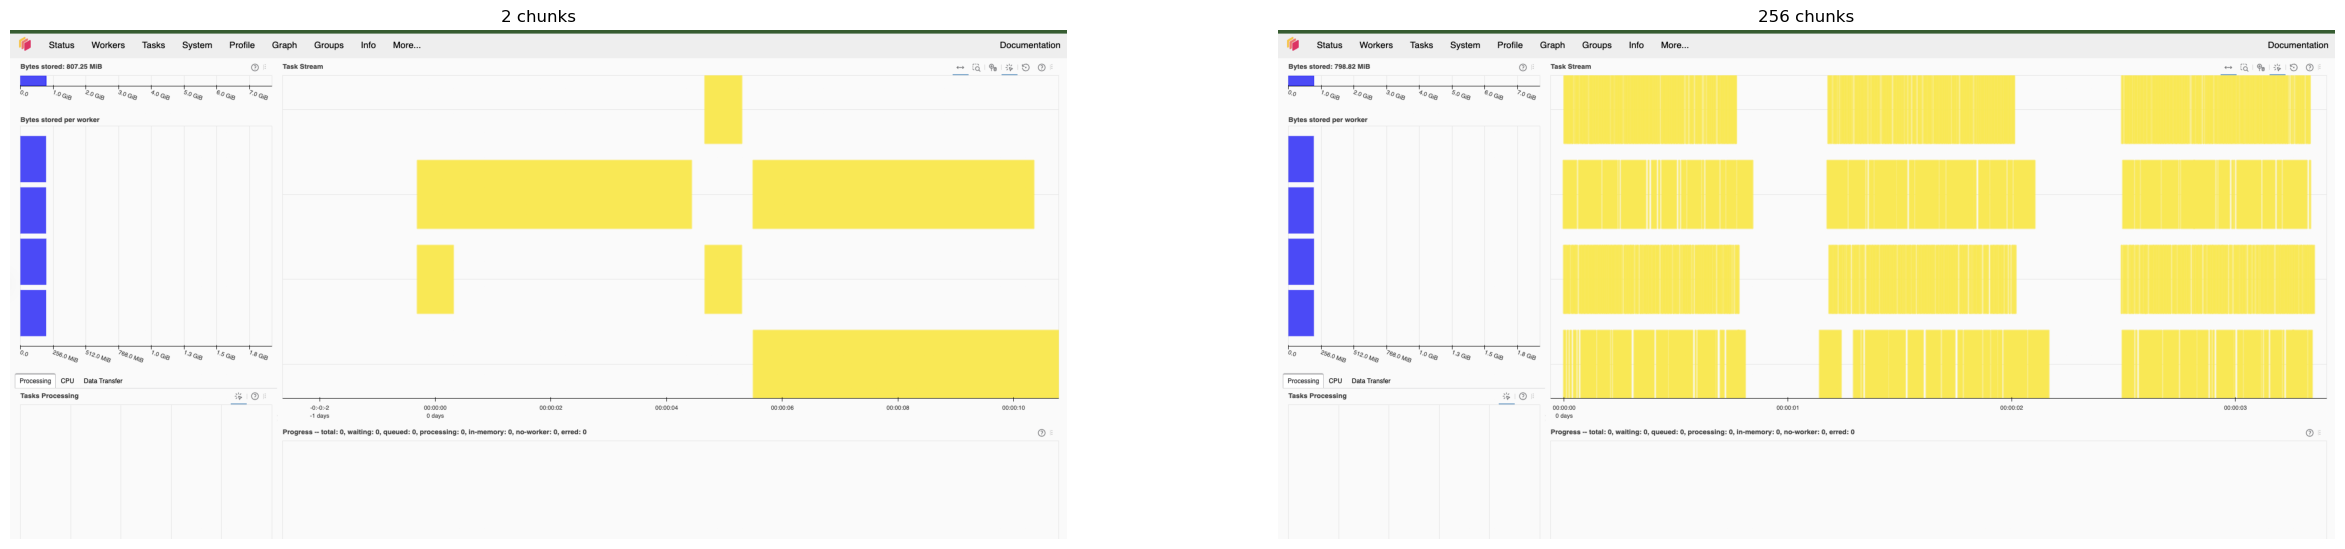

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('2_chunks.png')
img2 = mpimg.imread('256_chunks.png')

fig, ax = plt.subplots( 1,2, figsize=(30,10) )
ax[0].imshow(img1)
ax[0].set_title('2 chunks')
ax[0].axis('off')
ax[1].imshow(img2)
ax[1].set_title('256 chunks')
ax[1].axis('off')

plt.show()

Worker utilisation — are all workers busy throughout, or do some sit idle? 

*Based on the experiment with 2 chunks, it is quite easy to see that 2 workers at the beginning are actually in idle, while 2 other workers are busy*


Straggler tasks — do a few slow chunks delay the whole computation?

*Again, based on the experiment with 2 chunks, it is easy to see that there are definitely chunks that takes longer to finish than others. This slows down the computation. The image above indicates three tasks that takes way longer than other tasks.*

Task stream colour pattern — uniform or uneven?

*I only have a single colour for the tasks in my Dask dashboard, as the code only adds a single type of task to the Dask client.
However, despite the uniform colour, the unbalanced load distribution is still very easy to observe, especially for the experiment with 2 chunks. The image above indicates clearly, that some workers get tasks with smaller run time than others, meaning that we have straggler tasks present*

**Exercise 3: Load Balance in a Compute-Intensive Region**

Results using [ max_iter=1000, X_MIN=-0.75, X_MAX=-0.74, Y_MIN=0.099, Y_MAX=0.109, grid size=4096x4096, 4 workers ]

Optimal n_chunks: 64, walltime: 7.761, sp: 5.924, lif: -0.325

Min lif: -0.325 using n_chunks: 64, Min walltime: 7.761

Serial baseline walltime: 45.971s

| n_chunks | walltime (s) |    vs 1x |  speedup | lif |
|-------|-------|-------|-------|-------|
|       1 |   28.411 |    0.618 |    1.618 |    1.472
|       2 |   19.495 |    0.424 |    2.358 |    0.696
|       4 |   17.837 |    0.388 |    2.577 |    0.552
|       6 |   16.351 |    0.356 |    2.812 |    0.423
|       8 |   15.711 |    0.342 |    2.926 |    0.367
|      10 |   11.137 |    0.242 |    4.128 |   -0.031
|      12 |   13.331 |    0.290 |    3.448 |    0.160
|      16 |   10.933 |    0.238 |    4.205 |   -0.049
|      24 |   10.062 |    0.219 |    4.569 |   -0.125
|      32 |    8.751 |    0.190 |    5.253 |   -0.239
|      64 |    7.761 |    0.169 |    5.924 |   -0.325

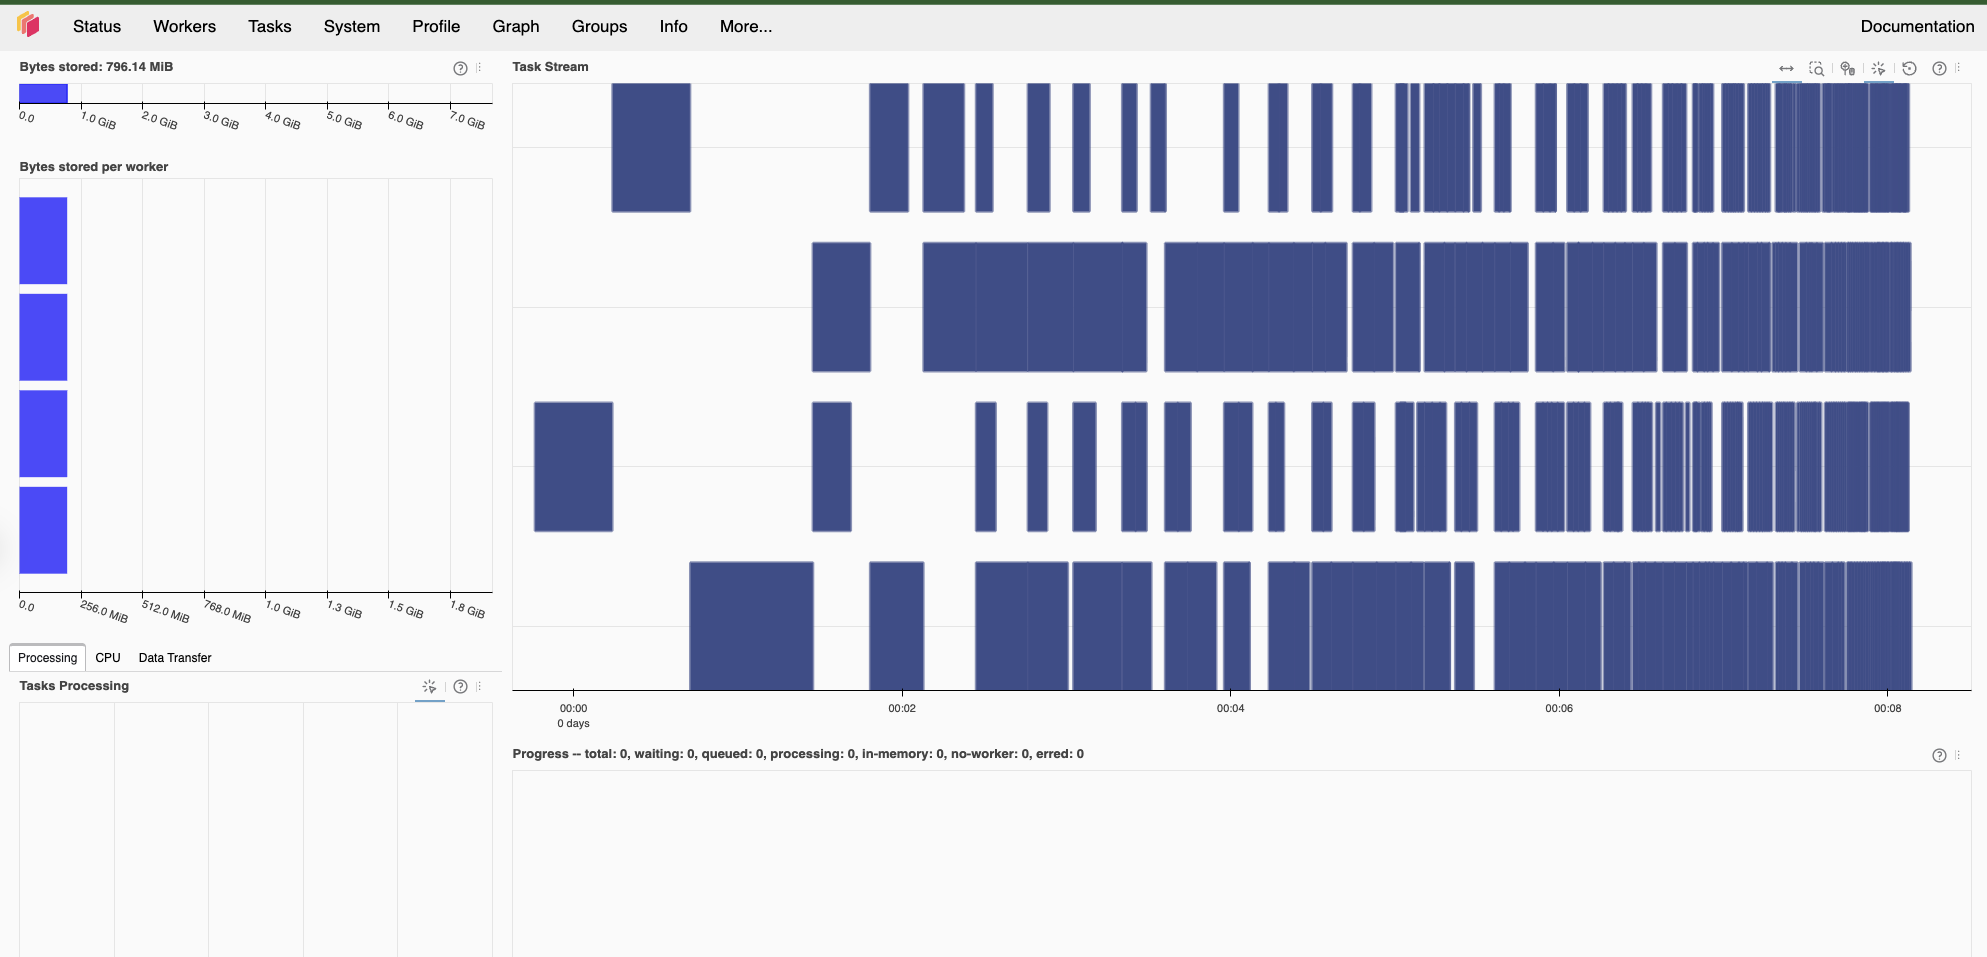

In [7]:
from IPython.display import Image, display
display(Image(filename="l07_ex3.png", width=1000))

Does the optimal chunk size change?

*Using grid size of 4096x4096 and 4 workers, the optimal chunk size does not change. It still lies at using 64 chunks. However, an interesting observation is that the speedup is higher. In fact, it lies at almost 6, when the previous speedup for 64 chunks lied at about 4.8*

Is load balance better or worse? Check the dashboard task stream.

*Considering the image of the task stream above, the load balance is not perfect. Some workers are occassionally idle compared to other workers.
Yet, with that said, the overall load balance looks good. The more compute-heavy region requires a more similar amount of iterations, resulting in a more uniform workload across chunks.*

How does wall time compare to the default view at the same N?

*The wall time for this experiment is much higher than the previous experiment. This is most likely because in this experiment we are testing with a 10 times higher maximum iteration, meaning that more time will be spent looping over the pixels in a chunk. The walltime is also higher here because the selected region lies close to the boundary of the Mandelbrot set, where many points require a large number of iterations before divergence is found. Consequently, most of the pixels in the grid will require a close number of iterations to the maximum iteration count or even lie at the maximum iteration count.*

### Speedup table

**Benchmark Table (based on results from MP1 report, multiprocessing, Dask local and Dask Strato experiments, all using 1024x1024 as grid size)**
| Version   | Time | Speedup |
| -------- | ------- | ------- |
| Naive    | 10.260s | 1x      |
| Numpy    | 0.870s  | 11.8x   |
| Numba    | 0.075s  | 136.9x  |
| Numba + multiprocessing | 0.028s  | 366.4x  |
| Dask Local | 0.073s  | 140.5x  |
| Dask Strato | 0.065s  | 157.84x  |

---

# Reflection

All the experiments with multiprocessing and Dask local was conducted with a grid size of 1024x1024.
However, the experiments with Dask on a Strato cluster was conducted with a larger grid sizes, that is 4096x4096 and 16384x16384.
The reason, that the applied grid sizes were much bigger for the experiments with Dask on a Strato cluster is due to 1024x1024 is too small, meaning that the overhead time from the network connectivity between the nodes in the cluster, dominates over the time it takes to execute the computation tasks. The experiments with multiprocessing and Dask local and also all the previous experiments, were all conducted on a single machine.

Multiprocessing with optimal number of chunks resulted in the highest speedup, when compared to all other experiments conducted in associated with this performance report. This was due to less overhead and efficient use of shared memory by the cores on the machine. By comparison, Dark local was a bit slower than multiprocessing, likely due to scheduler overhead. 

Based on the results presented in this work, it seems that if a computation task(s) are not too heavy, the optimal tool would be to use a single machine and multiprocessing. If the computation task(s) are very heavy and if scalability and fault tolerance is important, the better tool for the job would be Dask on a cluster.